## 1) Création de l'entité initiale

On commence avec un catalogue de fichiers CSV qui contiennent les données de nos entreprises. On cherche à trouver, stocker et analyser les données des trois entreprises : **Google** (`0878.065.378`), **Apple** (`0836.157.420`) et **SNCB** (`0203.430.576`).

Les fichiers KBO Open Data se trouvent dans `./data/kbo/` :

| Fichier | Contenu |
|---|---|
| `enterprise.csv` | Statut, forme juridique, date de création |
| `denomination.csv` | Dénominations officielles (FR / NL) |
| `address.csv` | Adresses (siège, exploitation…) |
| `activity.csv` | Codes d'activité NACE |
| `contact.csv` | Téléphone, e-mail, site web |
| `establishment.csv` | Unités d'établissement |
| `code.csv` | Table de correspondance des codes → libellés |


### 🔍 Recherche — Google

In [1]:
## Chargement des fichiers KBO depuis HDFS
# Les fichiers CSV KBO sont stockés sur HDFS sous /data/kbo/ (utilisé en local)
# Charger chaque fichier avec spark.read.csv() ou pd.read_csv()
# Définir les numéros d'entreprise et les fonctions get_entity() / afficher_entity()

GOOGLE_NUM = "0878.065.378"
APPLE_NUM  = "0836.157.420"
SNCB_NUM   = "0203.430.576"

import pandas as pd
import os

KBO_PATH = "./data/kbo"

enterprise   = pd.read_csv(os.path.join(KBO_PATH, "enterprise.csv"),   encoding="utf-8", low_memory=False)
denomination = pd.read_csv(os.path.join(KBO_PATH, "denomination.csv"), encoding="utf-8", low_memory=False)
address      = pd.read_csv(os.path.join(KBO_PATH, "address.csv"),      encoding="utf-8", low_memory=False)
activity     = pd.read_csv(os.path.join(KBO_PATH, "activity.csv"),     encoding="utf-8", low_memory=False)
contact      = pd.read_csv(os.path.join(KBO_PATH, "contact.csv"),      encoding="utf-8", low_memory=False)
establishment = pd.read_csv(os.path.join(KBO_PATH, "establishment.csv"), encoding="utf-8", low_memory=False)

def get_entity(num):
    return {
        "numero":         num,
        "infos":          enterprise  [enterprise  ["EnterpriseNumber"] == num],
        "denominations":  denomination[denomination["EntityNumber"]     == num],
        "adresses":       address     [address     ["EntityNumber"]     == num],
        "activites":      activity    [activity    ["EntityNumber"]     == num],
        "contacts":       contact     [contact     ["EntityNumber"]     == num],
        "etablissements": establishment[establishment["EnterpriseNumber"] == num],
    }


def afficher_entity(entity):
    infos  = entity["infos"].iloc[0] if not entity["infos"].empty else {}
    denoms = entity["denominations"]
    num    = entity["numero"]

    def get(col):
        return infos[col] if col in infos.index else "N/A"

    def fmt(val, width=3):
        try:
            return str(int(float(val))).zfill(width)
        except:
            return str(val)

    nom_df = denoms[denoms["TypeOfDenomination"].apply(fmt) == "001"]
    if not nom_df.empty:
        fr = nom_df[nom_df["Language"].astype(str) == "1"]
        nom = fr.iloc[0]["Denomination"] if not fr.empty else nom_df.iloc[0]["Denomination"]
    else:
        nom = num

    ligne = "=" * 60
    print(f"\n{ligne}")
    print(f"  {nom}  ({num})")
    print(f"{ligne}")

    champs = [
        ("Statut",              "Status",              None),
        ("Situation juridique", "JuridicalSituation",  3),
        ("Forme juridique",     "JuridicalForm",       3),
        ("Type d'entreprise",   "TypeOfEnterprise",    3),
        ("Date de création",    "StartDate",           None),
    ]
    for label, col, width in champs:
        val = get(col)
        val = fmt(val, width) if width else str(val)
        print(f"  {label:<20}: {val}")

    addrs = entity["adresses"]
    if not addrs.empty:
        a = addrs[addrs["TypeOfAddress"].apply(fmt) == "001"]
        a = a.iloc[0] if not a.empty else addrs.iloc[0]
        rue   = a.get("StreetFR") or a.get("StreetNL") or ""
        num_r = a.get("HouseNumber") or ""
        cp    = a.get("Zipcode") or ""
        ville = a.get("MunicipalityFR") or a.get("MunicipalityNL") or ""
        print(f"  {'Adresse':<20}: {rue} {num_r}, {cp} {ville}".rstrip(", "))

    acts = entity["activites"]
    if not acts.empty:
        print(f"\n  Activités")
        for version in sorted(acts["NaceVersion"].dropna().unique(), reverse=True):
            print(f"    NACE {int(float(version))} :")
            for _, row in acts[acts["NaceVersion"] == version].iterrows():
                code    = row.get("NaceCode", "")
                classif = row.get("Classification", "")
                grp     = fmt(row.get("ActivityGroup", ""), 3)
                print(f"        {code}  [{classif}]  groupe {grp}")

    cts = entity["contacts"]
    def get_contact(type_):
        return cts[cts["ContactType"] == type_]["Value"].tolist() if not cts.empty else []
    print(f"\n  {'Téléphone':<20}: {get_contact('TEL')}")
    print(f"  {'Email':<20}: {get_contact('EMAIL')}")
    print(f"  {'Site web':<20}: {get_contact('WEB')}")

    print(f"\n  {'Etablissements':<20}: {len(entity['etablissements'])}")

    print(f"\n  Dénominations :")
    print(denoms[["Language", "TypeOfDenomination", "Denomination"]].to_string(index=False))
    print()

In [2]:
google = get_entity(GOOGLE_NUM)
afficher_entity(google)


  GOOGLE BELGIUM  (0878.065.378)
  Statut              : AC
  Situation juridique : 000
  Forme juridique     : 014
  Type d'entreprise   : 002
  Date de création    : 21-12-2005
  Adresse             : Chaussée d'Etterbeek 180, 1040 Bruxelles

  Activités
    NACE 2025 :
        73110  [MAIN]  groupe 006
        62900  [MAIN]  groupe 001
    NACE 2008 :
        73110  [MAIN]  groupe 006
        62090  [MAIN]  groupe 001
    NACE 2003 :
        74401  [MAIN]  groupe 006
        72600  [MAIN]  groupe 001

  Téléphone           : []
  Email               : []
  Site web            : []

  Etablissements      : 1

  Dénominations :
 Language  TypeOfDenomination   Denomination
        2                   1 GOOGLE BELGIUM



### 🔍 Recherche — Apple

In [3]:
apple = get_entity(APPLE_NUM)
afficher_entity(apple)


  APPLE RETAIL BELGIUM  (0836.157.420)
  Statut              : AC
  Situation juridique : 000
  Forme juridique     : 610
  Type d'entreprise   : 002
  Date de création    : 06-05-2011
  Adresse             : Boulevard Saint-Lazare 4-10, 1210 Saint-Josse-ten-Noode

  Activités
    NACE 2025 :
        47400  [MAIN]  groupe 006
        47400  [MAIN]  groupe 001
    NACE 2008 :
        47410  [MAIN]  groupe 006
        47410  [MAIN]  groupe 001

  Téléphone           : []
  Email               : []
  Site web            : []

  Etablissements      : 2

  Dénominations :
 Language  TypeOfDenomination         Denomination
        2                   1 APPLE RETAIL BELGIUM



### 🔍 Recherche — SNCB

In [4]:
sncb = get_entity(SNCB_NUM)
afficher_entity(sncb)


  SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES  (0203.430.576)
  Statut              : AC
  Situation juridique : 000
  Forme juridique     : 114
  Type d'entreprise   : 002
  Date de création    : 01-01-1968
  Adresse             : Rue de France 56, 1060 Saint-Gilles

  Activités
    NACE 2025 :
        80010  [SECO]  groupe 001
        49110  [MAIN]  groupe 001
    NACE 2008 :
        80100  [SECO]  groupe 001
        49100  [MAIN]  groupe 001
    NACE 2003 :
        74601  [SECO]  groupe 001

  Téléphone           : []
  Email               : []
  Site web            : []

  Etablissements      : 270

  Dénominations :
 Language  TypeOfDenomination                                    Denomination
        1                   1     SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES
        1                   2                                            SNCB
        2                   1 NATIONALE MAATSCHAPPIJ DER BELGISCHE SPOORWEGEN
        2                   2                             

### 🔄 Traduction des codes CSV

On traduit maintenant les codes issus des fichiers CSV en valeurs lisibles (libellés, catégories, etc.).

In [5]:
code = pd.read_csv(os.path.join(KBO_PATH, "code.csv"), encoding="utf-8", low_memory=False)

LANG = "1"

def traduire(category, code_val, lang=LANG):
    """Traduit un code KBO en libellé lisible."""
    res = code[
        (code["Category"] == category) &
        (code["Code"]     == str(code_val)) &
        (code["Language"] == lang)
    ]
    if res.empty and lang != "FR":          
        res = code[
            (code["Category"] == category) &
            (code["Code"]     == str(code_val)) &
            (code["Language"] == "FR")
        ]
    if res.empty:
        return str(code_val)              
    return res.iloc[0]["Description"]

def afficher_entity_code(entity):
    infos  = entity["infos"].iloc[0] if not entity["infos"].empty else {}
    denoms = entity["denominations"]
    num    = entity["numero"]

    def get(col):
        return infos[col] if col in infos.index else "N/A"

    def fmt_code(val, width=3):
        """Convertit 14.0 ou '14' en '014'."""
        try:
            return str(int(float(val))).zfill(width)
        except:
            return str(val)

    nom_df = denoms[denoms["TypeOfDenomination"].apply(fmt_code) == "001"]
    if not nom_df.empty:
        fr = nom_df[nom_df["Language"].apply(fmt_code) == "001"]  # FR=1→001? 
        # Language : 1=FR dans code.csv
        fr = nom_df[nom_df["Language"].astype(str).str.zfill(1) == "1"]
        nom = fr.iloc[0]["Denomination"] if not fr.empty else nom_df.iloc[0]["Denomination"]
    else:
        nom = num

    ligne = "=" * 60
    print(f"\n{ligne}")
    print(f"  {nom}  ({num})")
    print(f"{ligne}")

    champs = [
        ("Statut",              "Status",             "Status",             None),
        ("Situation juridique", "JuridicalSituation", "JuridicalSituation", 3),
        ("Forme juridique",     "JuridicalForm",      "JuridicalForm",      3),
        ("Type d'entreprise",   "TypeOfEnterprise",   "TypeOfEnterprise",   None),
    ]
    for label, col, category, width in champs:
        raw = get(col)
        code_fmt = fmt_code(raw, width) if width else str(raw)
        print(f"  {label:<20}: {traduire(category, code_fmt)}")
    print(f"  {'Date de création':<20}: {get('StartDate')}")

    addrs = entity["adresses"]
    if not addrs.empty:
        a = addrs[addrs["TypeOfAddress"].apply(fmt_code) == "001"]
        a = a.iloc[0] if not a.empty else addrs.iloc[0]
        rue   = a.get("StreetFR") or a.get("StreetNL") or ""
        num_r = a.get("HouseNumber") or ""
        cp    = a.get("Zipcode") or ""
        ville = a.get("MunicipalityFR") or a.get("MunicipalityNL") or ""
        print(f"  {'Adresse':<20}: {rue} {num_r}, {cp} {ville}".rstrip(", "))

    acts = entity["activites"]
    if not acts.empty:
        print(f"\n  Activités")
        versions = sorted(acts["NaceVersion"].dropna().unique(), reverse=True)
        for version in versions:
            nace_cat = f"Nace{int(float(version))}"   # "2025.0" → "Nace2025"
            print(f"    NACE {int(float(version))} :")
            for _, row in acts[acts["NaceVersion"] == version].iterrows():
                code_val = str(row.get("NaceCode", ""))
                classif  = fmt_code(row.get("Classification", ""), 0)
                classif  = traduire("Classification", classif)
                grp      = fmt_code(row.get("ActivityGroup", ""), 3)
                grp_desc  = traduire("ActivityGroup", grp)
                nace_desc = traduire(nace_cat, code_val)
                print(f"        {code_val}  [{classif}]  {grp_desc} — {nace_desc}")

    cts = entity["contacts"]
    def get_contact(type_):
        return cts[cts["ContactType"] == type_]["Value"].tolist() if not cts.empty else []
    print(f"\n  {'Téléphone':<20}: {get_contact('TEL')}")
    print(f"  {'Email':<20}: {get_contact('EMAIL')}")
    print(f"  {'Site web':<20}: {get_contact('WEB')}")

    print(f"\n  {'Etablissements':<20}: {len(entity['etablissements'])}")

    print(f"\n  Dénominations :")
    denoms_aff = denoms.copy()
    denoms_aff["Language"]          = denoms_aff["Language"].apply(lambda x: traduire("Language", str(x)))
    denoms_aff["TypeOfDenomination"] = denoms_aff["TypeOfDenomination"].apply(lambda x: traduire("TypeOfDenomination", fmt_code(x)))
    print(denoms_aff[["Language", "TypeOfDenomination", "Denomination"]].to_string(index=False))
    print()


In [6]:
## output after code transformations
afficher_entity_code(google)


  GOOGLE BELGIUM  (0878.065.378)
  Statut              : Actif
  Situation juridique : Situation normale
  Forme juridique     : Société anonyme
  Type d'entreprise   : Personne morale
  Date de création    : 21-12-2005
  Adresse             : Chaussée d'Etterbeek 180, 1040 Bruxelles

  Activités
    NACE 2025 :
        73110  [Activité principale]  Activités ONSS — Activités d’agence de publicité
        62900  [Activité principale]  Activités TVA — Autres activités de service informatique
    NACE 2008 :
        73110  [Activité principale]  Activités ONSS — Activités des agences de publicité
        62090  [Activité principale]  Activités TVA — Autres activités informatiques
    NACE 2003 :
        74401  [Activité principale]  Activités ONSS — Agences de publicité
        72600  [Activité principale]  Activités TVA — Autres activités rattachées à l'informatique

  Téléphone           : []
  Email               : []
  Site web            : []

  Etablissements      : 1

  Dénominat

In [7]:
afficher_entity_code(apple)


  APPLE RETAIL BELGIUM  (0836.157.420)
  Statut              : Actif
  Situation juridique : Situation normale
  Forme juridique     : Société à responsabilité limitée
  Type d'entreprise   : Personne morale
  Date de création    : 06-05-2011
  Adresse             : Boulevard Saint-Lazare 4-10, 1210 Saint-Josse-ten-Noode

  Activités
    NACE 2025 :
        47400  [Activité principale]  Activités ONSS — Commerce de détail d’équipements de l’information et de la communication
        47400  [Activité principale]  Activités TVA — Commerce de détail d’équipements de l’information et de la communication
    NACE 2008 :
        47410  [Activité principale]  Activités ONSS — Commerce de détail d'ordinateurs, d'unités périphériques et de logiciels en magasin spécialisé
        47410  [Activité principale]  Activités TVA — Commerce de détail d'ordinateurs, d'unités périphériques et de logiciels en magasin spécialisé

  Téléphone           : []
  Email               : []
  Site web            

In [8]:
afficher_entity_code(sncb)


  SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES  (0203.430.576)
  Statut              : Actif
  Situation juridique : Situation normale
  Forme juridique     : Société anonyme de droit public
  Type d'entreprise   : Personne morale
  Date de création    : 01-01-1968
  Adresse             : Rue de France 56, 1060 Saint-Gilles

  Activités
    NACE 2025 :
        80010  [Activité secondaire]  Activités TVA — Activités d’investigation et de sécurité privée
        49110  [Activité principale]  Activités TVA — Transport ferroviaire lourd de voyageurs
    NACE 2008 :
        80100  [Activité secondaire]  Activités TVA — Activités de sécurité privée
        49100  [Activité principale]  Activités TVA — Transport ferroviaire de voyageurs autre qu'urbain et suburbain
    NACE 2003 :
        74601  [Activité secondaire]  Activités TVA — Entreprise de gardiennage et service de sécurité

  Téléphone           : []
  Email               : []
  Site web            : []

  Etablissements      : 270



---
## 2) Informations supplémentaires externes (KBO)

À partir d'ici, on récupère des données plus riches depuis le **Carrefour des Entreprises Belges (KBO/BCE)**.

URL de référence :  
`https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html?ondernemingsnummer=<NUMERO>`

Exemple : https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html?ondernemingsnummer=203430576

In [9]:
!pip install requests beautifulsoup4

In [10]:
## Numéros d'entreprise (format KBO sans points pour l'URL)
## Scraping KBO pour chaque entreprise
# → récupérer le HTML de la page et parser les sections ci-dessous

import requests
from bs4 import BeautifulSoup
import re

BASE_URL = "https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html"

GOOGLE_NUM_URL = "878065378"
APPLE_NUM_URL  = "836157420"
SNCB_NUM_URL   = "203430576"

def scrape_kbo(num_url):
    url = f"{BASE_URL}?ondernemingsnummer={num_url}&lang=fr"
    resp = requests.get(url, timeout=10)
    soup = BeautifulSoup(resp.text, "html.parser")

    data = {"url": url}

    for tr in soup.find_all("tr"):
        tds = tr.find_all("td")
        if len(tds) >= 2:
            label = tds[0].get_text(strip=True).rstrip(":")
            valeur = tds[1].get_text(" ", strip=True)
            if label:
                data[label] = valeur

    activites = []
    for a in soup.find_all("a", href=re.compile("naceToelichting")):
        code = a.get_text(strip=True).replace(".", "")
        description = ""
        parent_text = a.parent.get_text(" ", strip=True)
        if "-" in parent_text:
            description = parent_text.split("-", 1)[-1].strip()
        activites.append(f"{code} - {description}")
    data["activites_nace"] = activites

    dirigeants_raw = []
    for tr in soup.find_all("tr"):
        tds = tr.find_all("td")
        if len(tds) >= 3:
            role = tds[0].get_text(strip=True).rstrip(":")
            nom  = tds[1].get_text(strip=True).split("Depuis")[0].strip()
            nom  = re.sub(r'\s+', ' ', nom).replace(" ,", ",")
            if role and nom and len(role) < 80 and len(nom) < 80:
                dirigeants_raw.append({"nom": nom, "qualite": role})
    data["dirigeants_raw"] = dirigeants_raw

    liens_raw    = []
    section_tr   = None
    all_tds_I    = soup.find_all("td", class_="I")
    for td in all_tds_I:
        if "Liens entre entités" in td.get_text():
            section_tr = td.find_parent("tr")
            break

    if section_tr:
        for tr in section_tr.find_next_siblings("tr"):
            if tr.find("td", class_="I"):
                break
            a = tr.find("a", href=re.compile("ondernemingsnummer"))
            if not a:
                continue
            numero    = a.get_text(strip=True)
            texte     = re.sub(r'\s+', ' ', tr.get_text(" ", strip=True))
            nom_m     = re.search(r'\(([^)]+)\)', texte)
            entite    = nom_m.group(1).strip() if nom_m else "N/A"
            date_m    = re.search(r'depuis\s+le\s+([\d\w\s]+\d{4})', texte, re.IGNORECASE)
            date_lien = date_m.group(1).strip() if date_m else "N/A"
            nat_m     = re.search(r'\)\s+(.+?)\s+depuis', texte, re.IGNORECASE)
            nature    = nat_m.group(1).strip() if nat_m else "N/A"
            liens_raw.append({"entite": entite, "numero": numero,
                               "nature": nature, "date_lien": date_lien})

    data["liens_raw"] = liens_raw

    return data

def afficher_scrape(data):
    champs = [
        "Numéro d'entreprise", "Statut", "État juridique",
        "Date de début", "Type d'entité", "Forme juridique",
        "Adresse du siège", "Numéro de téléphone",
        "Numéro de fax", "E-mail", "Adresse web",
        "Nombre d'unités d'établissement (UE)",
    ]
    for champ in champs:
        if champ in data:
            print(f"  {champ:<40}: {data[champ]}")
    print()


In [11]:
data = scrape_kbo(GOOGLE_NUM_URL)
afficher_scrape(data)

  Numéro d'entreprise                     : 0878.065.378
  Statut                                  : Actif
  Date de début                           : 21 décembre 2005
  Type d'entité                           : Personne morale
  Adresse du siège                        : Chaussée d'Etterbeek 180 1040 Bruxelles Info supplémentaires: GooglePlex Depuis le 12 novembre 2009
  Numéro de téléphone                     : Pas de données reprises dans la BCE.
  Numéro de fax                           : Pas de données reprises dans la BCE.
  E-mail                                  : Pas de données reprises dans la BCE.
  Adresse web                             : Pas de données reprises dans la BCE.
  Nombre d'unités d'établissement (UE)    : 1 Données et Activités par UE



In [12]:
data = scrape_kbo(APPLE_NUM_URL)
afficher_scrape(data)

  Numéro d'entreprise                     : 0836.157.420
  Statut                                  : Actif
  Date de début                           : 6 mai 2011
  Type d'entité                           : Personne morale
  Adresse du siège                        : Boulevard Saint-Lazare 4-10 1210 Saint-Josse-ten-Noode Info supplémentaires: Botanic Tower 6de verdieping Depuis le 1 février 2025
  Numéro de téléphone                     : Pas de données reprises dans la BCE.
  Numéro de fax                           : Pas de données reprises dans la BCE.
  E-mail                                  : Pas de données reprises dans la BCE.
  Adresse web                             : Pas de données reprises dans la BCE.
  Nombre d'unités d'établissement (UE)    : 2 Liste UE - Données et Activités par UE



In [13]:
data = scrape_kbo(SNCB_NUM_URL)
afficher_scrape(data)

  Numéro d'entreprise                     : 0203.430.576
  Statut                                  : Actif
  Date de début                           : 1 janvier 1968
  Type d'entité                           : Personne morale
  Adresse du siège                        : Rue de France 56 1060 Saint-Gilles Depuis le 1 janvier 2014
  Numéro de téléphone                     : Pas de données reprises dans la BCE.
  Numéro de fax                           : Pas de données reprises dans la BCE.
  E-mail                                  : Pas de données reprises dans la BCE.
  Adresse web                             : Pas de données reprises dans la BCE.
  Nombre d'unités d'établissement (UE)    : 270 Liste UE - Données et Activités par UE



---
### 2.1) Informations Générales

| Champ | Valeur |
|---|---|
| Dénomination | |
| Numéro d'entreprise | |
| Adresse | |
| Activité principale | |
| Effectif | |
| Date de création | |

In [14]:
## Extraction — Informations Générales
# denomination     = ...
# numero           = ...
# adresse          = ...
# activite_principale = ...
# effectif         = ...
# date_creation    = ...


def extraire_infos(data):
    denomination = data.get("Dénomination", "N/A")
    denomination = denomination.split("Dénomination")[0].strip()

    numero       = data.get("Numéro d'entreprise", "N/A")
    adresse      = data.get("Adresse du siège", "N/A")
    adresse      = adresse.split("Depuis")[0].strip()

    date_creation = data.get("Date de début", "N/A")

    effectif_raw = data.get("Nombre d'unités d'établissement (UE)", "N/A")
    effectif     = effectif_raw.split()[0] if effectif_raw != "N/A" else "N/A"

    nace = data.get("activites_nace", [])
    activite_principale = nace[0].split("Depuis")[0].strip() if nace else "N/A"
    for k, v in data.items():
        if "2025" in k and ("TVA" in k or "Nace" in k or "activit" in k.lower()):
            activite_principale = v.strip()
            break

    return {
        "denomination":        denomination,
        "numero":              numero,
        "adresse":             adresse,
        "activite_principale": activite_principale,
        "effectif":            effectif,
        "date_creation":       date_creation,
    }


In [15]:
infos_google = extraire_infos(scrape_kbo(GOOGLE_NUM_URL))
for k, v in infos_google.items():
    print(f"{k:<25}: {v[:80] if isinstance(v, str) else v}")

denomination             : GOOGLE BELGIUM
numero                   : 0878.065.378
adresse                  : Chaussée d'Etterbeek 180 1040 Bruxelles Info supplémentaires: GooglePlex
activite_principale      : 62900 - Autres activités de service informatique
effectif                 : 1
date_creation            : 21 décembre 2005


In [16]:
infos_apple  = extraire_infos(scrape_kbo(APPLE_NUM_URL))
for k, v in infos_apple.items():
    print(f"{k:<25}: {v[:80] if isinstance(v, str) else v}")

denomination             : APPLE RETAIL BELGIUM
numero                   : 0836.157.420
adresse                  : Boulevard Saint-Lazare 4-10 1210 Saint-Josse-ten-Noode Info supplémentaires: Bot
activite_principale      : 47400 - Commerce de détail d’équipements de l’information et de la communication
effectif                 : 2
date_creation            : 6 mai 2011


In [17]:
infos_sncb   = extraire_infos(scrape_kbo(SNCB_NUM_URL))
for k, v in infos_sncb.items():
    print(f"{k:<25}: {v[:80] if isinstance(v, str) else v}")

denomination             : SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES
numero                   : 0203.430.576
adresse                  : Rue de France 56 1060 Saint-Gilles
activite_principale      : 80010 - Activités d’investigation et de sécurité privée
effectif                 : 270
date_creation            : 1 janvier 1968


---
### 2.2) Informations Juridiques

| Champ | Valeur |
|---|---|
| Forme juridique | |
| Numéro de TVA | |
| Situation juridique | |
| Capital social | |
| Assemblée générale | |
| Date de fin de l'année comptable | |

In [18]:
## Extraction — Informations Juridiques
# forme_juridique     = ...
# numero_tva          = ...
# situation_juridique = ...
# capital_social      = ...
# assemblee_generale  = ...
# fin_annee_comptable = ...


def extraire_juridique(data):
    forme_juridique     = data.get("Forme légale", "N/A")
    forme_juridique     = forme_juridique.split("Depuis")[0].strip()

    numero              = data.get("Numéro d'entreprise", "N/A")
    numero_tva          = "BE" + numero.replace(".", "") if numero != "N/A" else "N/A"

    situation_juridique = data.get("Situation juridique", "N/A")
    situation_juridique = situation_juridique.split("Depuis")[0].strip()

    capital_social      = data.get("Capital", "N/A")

    assemblee_generale  = data.get("Assemblée générale", "N/A")

    fin_annee_comptable = data.get("Date de fin de l'année comptable", "N/A")

    return {
        "forme_juridique":     forme_juridique,
        "numero_tva":          numero_tva,
        "situation_juridique": situation_juridique,
        "capital_social":      capital_social,
        "assemblee_generale":  assemblee_generale,
        "fin_annee_comptable": fin_annee_comptable,
    }


In [19]:
data = scrape_kbo(GOOGLE_NUM_URL)
for k, v in extraire_juridique(data).items():
    print(f"  {k:<25}: {v}")

  forme_juridique          : Société anonyme
  numero_tva               : BE0878065378
  situation_juridique      : Situation normale
  capital_social           : 770.000,00 EUR
  assemblee_generale       : juin
  fin_annee_comptable      : 31 décembre


In [20]:
data = scrape_kbo(APPLE_NUM_URL)
for k, v in extraire_juridique(data).items():
    print(f"  {k:<25}: {v}")

  forme_juridique          : Société à responsabilité limitée
  numero_tva               : BE0836157420
  situation_juridique      : Situation normale
  capital_social           : N/A
  assemblee_generale       : mars
  fin_annee_comptable      : 24 septembre


In [21]:
data = scrape_kbo(SNCB_NUM_URL)
for k, v in extraire_juridique(data).items():
    print(f"  {k:<25}: {v}")

  forme_juridique          : Société anonyme de droit public
  numero_tva               : BE0203430576
  situation_juridique      : Situation normale
  capital_social           : 249.022.345,57 EUR
  assemblee_generale       : mai
  fin_annee_comptable      : 31 décembre


---
### 2.3) Activités

Liste de chaque domaine d'activité avec son code NACE/ONSS.

| Code | Description |
|---|---|

In [22]:
## Extraction — Activités
# activites = [
#   {"code": "XXXXX", "description": "..."},
#   ...
# ]


def extraire_activites(data):
    activites = []
    for entree in data.get("activites_nace", []):
        entree = entree.split("Depuis")[0].strip()
        if " - " in entree:
            code, _, description = entree.partition(" - ")
            activites.append({
                "code":        code.strip(),
                "description": description.strip(),
            })
    return activites


In [23]:
data = scrape_kbo(GOOGLE_NUM_URL)
for a in extraire_activites(data):
    print(f"  {a['code']} — {a['description']}")

  62900 — Autres activités de service informatique
  73110 — Activités d’agence de publicité


In [24]:
data = scrape_kbo(APPLE_NUM_URL)
for a in extraire_activites(data):
        print(f"  {a['code']} — {a['description']}")

  47400 — Commerce de détail d’équipements de l’information et de la communication
  47400 — Commerce de détail d’équipements de l’information et de la communication


In [25]:
data = scrape_kbo(SNCB_NUM_URL)
for a in extraire_activites(data):
    print(f"  {a['code']} — {a['description']}")

  80010 — Activités d’investigation et de sécurité privée
  49110 — Transport ferroviaire lourd de voyageurs


---
### 2.4) Dirigeants et Représentants

Liste de chaque dirigeant avec sa ou ses qualité(s).

| Nom | Qualité(s) |
|---|---|

In [26]:
## Extraction — Dirigeants
# dirigeants = [
#   {"nom": "...", "qualites": ["...", "..."]},
#   ...
# ]

def extraire_dirigeants(data):
    from collections import defaultdict
    exclusions = {"Numéro d'entreprise", "Statut", "Adresse du siège", 
                  "Forme légale", "Type d'entité", ""}
    par_nom = defaultdict(list)
    for d in data.get("dirigeants_raw", []):
        if d["qualite"] not in exclusions and d["nom"] not in exclusions:
            par_nom[d["nom"]].append(d["qualite"])
    return [{"nom": nom, "qualites": qualites} for nom, qualites in par_nom.items()]


In [27]:
data = scrape_kbo(GOOGLE_NUM_URL)
for d in extraire_dirigeants(data):
    print(f"  {d['nom']:<30} {', '.join(d['qualites'])}")

  Fagan, Frank                   Administrateur
  KARAIVANOV, SVILEN             Administrateur
  Turschl, Gabor                 Administrateur, Administrateur délégué


In [28]:
data = scrape_kbo(APPLE_NUM_URL)
for d in extraire_dirigeants(data):
    print(f"  {d['nom']:<30} {', '.join(d['qualites'])}")

  GALA, TEJAS                    Administrateur
  KAM, WAN KEI                   Administrateur


In [29]:
data = scrape_kbo(SNCB_NUM_URL)
for d in extraire_dirigeants(data):
    print(f"  {d['nom']:<30} {', '.join(d['qualites'])}")

  Boelaert, Filip                Administrateur
  Bonaventure, Chanelle          Administrateur
  Douette, Emmanuel              Administrateur
  Durez, Martine                 Administrateur
  Georgin, Thibaut               Administrateur
  Glautier, Laurence             Administrateur
  Henry, Olivier                 Administrateur
  Mercenier, Eric                Administrateur
  Poot, An                       Administrateur
  Schalck, Daan                  Administrateur
  Sterckx, Dirk                  Administrateur
  Vanbesien, Wouter              Administrateur
  Vanderhenst, Maarten           Administrateur
  Dutordoir, Sophie              Personne déléguée à la gestion journalière


---
### 2.5) Liens entre Entités

Liste de chaque entité liée à l'entreprise.

| Entité | Numéro d'entreprise | Date du lien | Nature du lien | Statut actuel |
|---|---|---|---|---|

In [30]:
## Extraction — Liens entre entités
# liens = [
#   {
#     "entite": "...",
#     "numero": "...",
#     "date_lien": "...",
#     "nature": "...",
#     "statut": "..."
#   },
#   ...
# ]

## Extraction — Liens entre entités

def extraire_liens(data):
    return data.get("liens_raw", [])


In [31]:
# Cellule debug (optionnelle) — ou saute-la et exécute la cellule suivante
url = f"{BASE_URL}?ondernemingsnummer={GOOGLE_NUM_URL}&lang=fr"
resp = requests.get(url, timeout=10)
soup = BeautifulSoup(resp.text, "html.parser")

section_tr = None
for td in soup.find_all("td", class_="I"):
    if "Liens entre entités" in td.get_text():
        section_tr = td.find_parent("tr")
        break

print("section_tr trouvé:", section_tr is not None)

if section_tr:
    siblings = section_tr.find_next_siblings("tr")
    print("nb siblings:", len(siblings))
    for tr in siblings[:3]:
        a = tr.find("a", href=re.compile("ondernemingsnummer"))
        print("a trouvé:", a is not None)

section_tr trouvé: True
nb siblings: 4
a trouvé: False
a trouvé: False
a trouvé: False


In [32]:
for l in extraire_liens(scrape_kbo(GOOGLE_NUM_URL)):
        print(f"  {l['numero']:<15} {l['entite']:<40} {l['nature']:<30} {l['date_lien']}")

In [33]:
for l in extraire_liens(scrape_kbo(APPLE_NUM_URL)):
        print(f"  {l['numero']:<15} {l['entite']:<40} {l['nature']:<30} {l['date_lien']}")

In [34]:
for l in extraire_liens(scrape_kbo(SNCB_NUM_URL)):
        print(f"  {l['numero']:<15} {l['entite']:<40} {l['nature']:<30} {l['date_lien']}")

  0260.581.887    Financière TGV - HST-FIN                 est absorbée par cette entité  10 septembre 2004
  0419.345.054    L.A. GROUP                               est absorbée par cette entité  29 juin 2012
  0869.763.069    Société nationale des Chemins de Fer belges est absorbée par cette entité  1 janvier 2014
  0433.939.101    FONCIERE RUE DE FRANCE - VASTGOEDMAATSCHAPPIJ FRANKRIJKSTRAAT est absorbée par cette entité  1 janvier 2016
  0896.513.095    SOUTH STATION                            est absorbée par cette entité  1 janvier 2016
  0826.478.107    SPV LLN                                  est absorbée par cette entité  22 décembre 2017
  0446.601.757    EUROSTATION                              est absorbée par cette entité  26 octobre 2018
  0899.438.834    B-PARKING                                est absorbée par cette entité  2 juillet 2021
  0451.150.562    Eurogare                                 est absorbée par cette entité  17 décembre 2021
  0402.698.765    Railtou

---
### 2.6) Documents Juridiques (Statuts)

Source : https://statuts.notaire.be/stapor_v1/enterprise/{numero}/statutes

| Document | Date | Lien |
|---|---|---|

cree session call a la fin (recuperartion de la vrai session) 
creation de session
2 call 
vrai user agent sinon comprendre qu'on est pas un navigateur 
recuperation des autres cookies 
3 cookies necessaire 

429 -> rate limite -> rotaion de l'ip 


In [35]:
## Extraction — Documents juridiques (Statuts Notaire)
# STATUTS_URL = f"https://statuts.notaire.be/stapor_v1/enterprise/{numero}/statutes"
# params = {"enterpriseNumber": numero, "statuteStart": 0, "statuteCount": 5}
# → paginer et collecter tous les statuts disponibles

import requests

STATUTS_BASE = "https://statuts.notaire.be/stapor_v1/enterprise"

def extraire_statuts(numero_kbo, count=5):
    """
    Récupère les statuts notariaux depuis statuts.notaire.be.
    numero_kbo : format "0203.430.576"
    """
    # Supprimer les points pour l'URL
    num = numero_kbo.replace(".", "")
    url = f"{STATUTS_BASE}/{num}/statutes"

    statuts = []
    start   = 0

    while True:
        params = {
            "enterpriseNumber": num,
            "statuteStart":     start,
            "statuteCount":     count,
        }
        headers = {
            "Accept":     "application/json",
            "User-Agent": "Mozilla/5.0",
        }
        resp = requests.get(url, params=params, headers=headers, timeout=10)

        if resp.status_code != 200:
            print(f"Erreur {resp.status_code}")
            break

        try:
            data = resp.json()
        except Exception:
            print("Réponse non-JSON :", resp.text[:200])
            break

        items = data.get("statutes", data.get("results", []))
        if not items:
            break

        for s in items:
            statuts.append({
                "date":        s.get("date", "N/A"),
                "type":        s.get("type", s.get("statuteType", "N/A")),
                "description": s.get("description", s.get("title", "N/A")),
                "url_doc":     s.get("url", s.get("documentUrl", "N/A")),
            })

        if len(items) < count:
            break
        start += count

    return statuts

# Test
for nom, num in [("Google", GOOGLE_NUM), ("Apple", APPLE_NUM), ("SNCB", SNCB_NUM)]:
    print(f"\n>>> {nom}")
    statuts = extraire_statuts(num)
    if not statuts:
        print("  Aucun statut trouvé.")
    for s in statuts:
        print(f"  {s['date']:<15} {s['type']:<20} {s['description'][:50]}")




>>> Google
Réponse non-JSON : <!doctype html>
<html>
<head>
  <title></title>
  <style>
    html, body {
      margin: 0;
      padding: 0;
      background-color: white;
    }
  </style>
</head>
<body>
    <script>(function(z,y,c
  Aucun statut trouvé.

>>> Apple
Réponse non-JSON : <!doctype html>
<html>
<head>
  <title></title>
  <style>
    html, body {
      margin: 0;
      padding: 0;
      background-color: white;
    }
  </style>
</head>
<body>
    <script>(function(z,y,c
  Aucun statut trouvé.

>>> SNCB
Réponse non-JSON : <!doctype html>
<html>
<head>
  <title></title>
  <style>
    html, body {
      margin: 0;
      padding: 0;
      background-color: white;
    }
  </style>
</head>
<body>
    <script>(function(z,y,c
  Aucun statut trouvé.


---
### 2.7) Comptes Annuels

Source : https://consult.cbso.nbb.be/consult-enterprise/{numero}

**Stratégie de stockage :**
- **PDFs** — tous les dépôts depuis l'an 2000 → stockés sur HDFS sous `/data/nbb/pdfs/{numero}/{annee}.pdf`
- **CSVs** — tous les dépôts depuis 2021 (format tabulaire) → stockés sur HDFS sous `/data/nbb/csvs/{numero}/{annee}.csv`

> Les dépôts antérieurs à 2021 n'ont pas de CSV disponible (fichiers migrés — PDF uniquement).
> Exclure les comptes **consolidés** (modèle `mc-*`) et dédupliquer à **un seul dépôt par année** (préférer FR sur NL).

| Année fiscale | Date de publication | PDF | CSV |
|---|---|---|---|

In [36]:
!pip install hdfs

In [37]:
## Extraction — Comptes Annuels (NBB/CBSO) + stockage HDFS

import requests
import pandas as pd
import io
import time
from hdfs import InsecureClient

CBSO_API      = "https://consult.cbso.nbb.be/api/rs-consult/published-deposits"
CBSO_DOC_BASE = "https://consult.cbso.nbb.be/api/external/broker/public/deposits"
CBSO_BASE_URL = "https://consult.cbso.nbb.be/consult-enterprise"

HDFS_URL    = "http://localhost:9870"
HDFS_USER   = "root"  # obligatoire en local (user hdfs n'a pas les droits)
hdfs_client = InsecureClient(HDFS_URL, user=HDFS_USER)

_csv_inspecte = False


def get_cbso_session(numero):
    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; rv:152.0) Gecko/20100101 Firefox/152.0",
        "Accept": "application/json, text/plain, */*",
        "Accept-Language": "en-US,en;q=0.9",
        "Connection": "keep-alive",
    })
    r = session.get(
        CBSO_API,
        params={
            "enterpriseNumber": numero.replace(".", ""),
            "page": 0, "size": 1,
            "sort": ["periodEndDate,desc", "depositDate,desc"],
        },
        timeout=15,
    )
    print("Cookies reçus :", r.cookies.get_dict())
    print("Cookies session :", session.cookies.get_dict())
    session.headers["Referer"] = f"{CBSO_BASE_URL}/{numero}"
    return session


def fetch_depots(session, numero):
    depots, page = [], 0
    while True:
        params = {
            "enterpriseNumber": numero.replace(".", ""),
            "page": page, "size": 50,
            "sort": ["periodEndDate,desc", "depositDate,desc"],
        }
        print(f"\n[LOG] Requête CBSO_API")
        print(f"      URL    : {CBSO_API}")
        print(f"      Params : {params}")
        start = time.time()
        resp = session.get(CBSO_API, params=params, timeout=15)
        elapsed = time.time() - start
        print(f"      Status : {resp.status_code}")
        print(f"      Temps  : {elapsed:.2f}s")
        if resp.status_code != 200:
            print(f"      Erreur : {resp.text[:300]}")
            break
        if not resp.content:
            print("      Réponse vide")
            break
        data = resp.json()
        print(f"      Dépôts retournés : {len(data.get('content', []))}")
        print(f"      Dernière page    : {data.get('last', True)}")
        depots.extend(data.get("content", []))
        if data.get("last", True):
            break
        page += 1
    return depots


def filtrer_depots(depots):
    depots = [d for d in depots
              if "consolidé" not in d.get("modelName", "").lower()]
    par_annee = {}
    for d in depots:
        annee = str(d.get("periodEndDateYear", "?"))
        if annee not in par_annee:
            par_annee[annee] = d
        elif d.get("language") == "FR" and par_annee[annee].get("language") != "FR":
            par_annee[annee] = d
    return par_annee


def stocker_hdfs(session, numero, par_annee):
    global _csv_inspecte
    client = InsecureClient(HDFS_URL, user=HDFS_USER)
    for annee, depot in sorted(par_annee.items()):
        an, did = (int(annee) if str(annee).isdigit() else 0), depot["id"]
        time.sleep(1)

        if an >= 2021:
            r = session.get(f"{CBSO_DOC_BASE}/consult/csv/{did}", timeout=30)
            if r.status_code == 200:
                if not _csv_inspecte:
                    df_inspect = pd.read_csv(
                        io.BytesIO(r.content),
                        sep=",", header=None, names=["rubrique", "valeur"]
                    )
                    print(f"\n  [INSPECTION CSV {annee}]")
                    print(f"  Colonnes : {df_inspect.columns.tolist()}")
                    print(df_inspect.head(15).to_string())
                    print()
                    _csv_inspecte = True

                hdfs_path = f"/data/nbb/csvs/{numero}/{annee}.csv"
                with client.write(hdfs_path, overwrite=True) as f:
                    f.write(r.content)
                print(f"  CSV {annee} → {hdfs_path}  ({len(r.content)//1024} Ko)")
            else:
                print(f"  CSV non disponible pour {annee} ({r.status_code})")

        if an >= 2000:
            r = session.get(f"{CBSO_DOC_BASE}/pdf/{did}", timeout=30)
            if r.status_code == 200:
                hdfs_path = f"/data/nbb/pdfs/{numero}/{annee}.pdf"
                with client.write(hdfs_path, overwrite=True) as f:
                    f.write(r.content)
                print(f"  PDF {annee} → {hdfs_path}  ({len(r.content)//1024} Ko)")
            else:
                print(f"  PDF erreur {r.status_code} pour {annee}")


for nom, num in [("Google", GOOGLE_NUM), ("Apple", APPLE_NUM), ("SNCB", SNCB_NUM)]:
    print(f"\n>>> {nom}")
    session   = get_cbso_session(num.replace(".", ""))
    depots    = fetch_depots(session, num)
    par_annee = filtrer_depots(depots)
    print(f"  {len(depots)} dépôts bruts → {len(par_annee)} années uniques")
    for a, d in sorted(par_annee.items()):
        print(f"  {a}  [{d.get('language')}]  {d.get('modelName','')[:45]}  {d.get('importFileType')}")
    stocker_hdfs(session, num, par_annee)
    time.sleep(3)



>>> Google
Cookies reçus : {'ASLBSA': '00035e0590eeae688980183c5f382108885de38c4913ac0bdc2bd9bc1b3fd89b512b', 'ASLBSACORS': '00035e0590eeae688980183c5f382108885de38c4913ac0bdc2bd9bc1b3fd89b512b'}
Cookies session : {'ASLBSA': '00035e0590eeae688980183c5f382108885de38c4913ac0bdc2bd9bc1b3fd89b512b', 'ASLBSACORS': '00035e0590eeae688980183c5f382108885de38c4913ac0bdc2bd9bc1b3fd89b512b'}

[LOG] Requête CBSO_API
      URL    : https://consult.cbso.nbb.be/api/rs-consult/published-deposits
      Params : {'enterpriseNumber': '0878065378', 'page': 0, 'size': 50, 'sort': ['periodEndDate,desc', 'depositDate,desc']}
      Status : 200
      Temps  : 0.09s
      Dépôts retournés : 21
      Dernière page    : True
  21 dépôts bruts → 20 années uniques
  2006  [NL]  Volledig schema kapitaalvennootschap  XBRL
  2007  [NL]  Volledig schema kapitaalvennootschap  XBRL
  2008  [NL]  Volledig schema kapitaalvennootschap  XBRL
  2009  [NL]  Volledig schema kapitaalvennootschap  XBRL
  2010  [NL]  Volledig sch

---
### 2.8) Établissements

Liste de chaque établissement de l'entreprise.

| Numéro | Adresse | Date de création | Activité |
|---|---|---|---|

In [38]:
## Extraction — Établissements
# etablissements = [
#   {
#     "numero": "...",
#     "adresse": "...",
#     "date_creation": "...",
#     "activite": "..."
#   },
#   ...
# ]

import requests
from bs4 import BeautifulSoup
import re

VESTIGING_URL = "https://kbopub.economie.fgov.be/kbopub/vestiginglijst.html"

def scrape_etablissements(num_url, max_pages=None):
    """Scrape toutes les pages d'établissements d'une entreprise."""
    etablissements = []
    page = 1

    while True:
        params = {"ondernemingsnummer": num_url, "lang": "fr", "page": page}
        resp = requests.get(VESTIGING_URL, params=params, timeout=10)
        soup = BeautifulSoup(resp.text, "html.parser")

        rows = soup.select("table tr")[1:]  # skip header
        if not rows:
            break

        for tr in rows:
            tds = tr.find_all("td")
            if len(tds) < 5:
                continue

            statut       = tds[1].get_text(strip=True)
            numero       = tds[2].get_text(strip=True)
            date_creation = tds[3].get_text(strip=True).split("Depuis")[0].strip()
            denomination = tds[4].get_text(strip=True)
            denomination = None if "Pas de données" in denomination else denomination

            adresse_raw  = tds[5].get_text("  ", strip=True)
            adresse      = re.sub(r'\s+', ' ', adresse_raw).split("Depuis")[0].strip()

            etablissements.append({
                "numero":        numero,
                "statut":        statut,
                "date_creation": date_creation,
                "denomination":  denomination,
                "adresse":       adresse,
            })

        # Vérifier s'il y a une page suivante
        suivant = soup.find("a", string=re.compile("Suivant"))
        if not suivant or (max_pages and page >= max_pages):
            break
        page += 1

    return etablissements


def extraire_etablissements(num_kbo, num_url, max_pages=None):
    """Fusionne scraping web + activités depuis les CSV locaux."""
    ests = scrape_etablissements(num_url, max_pages=max_pages)

    for e in ests:
        num_clean = e["numero"].replace(".", "").replace(" ", "")
        num_fmt   = f"{num_clean[0]}{num_clean[1:4]}.{num_clean[4:7]}.{num_clean[7:]}" \
                    if len(num_clean) == 10 else e["numero"]
        actes = activity[activity["EntityNumber"] == num_fmt]
        if not actes.empty:
            a = actes[actes["NaceVersion"].astype(str).str.contains("2025")]
            a = a.iloc[0] if not a.empty else actes.iloc[0]
            e["activite"] = f"{a.get('NaceCode', '')} — {traduire('Nace2025', str(a.get('NaceCode', '')))}"
        else:
            e["activite"] = None

    return ests


In [39]:
ests = extraire_etablissements(GOOGLE_NUM, GOOGLE_NUM_URL, max_pages=2)
for e in ests[:5]:
    print(f"  {e['numero']:<20} {e['date_creation']:<20} {e['adresse'][:40]}")

  2.151.627.472        10 février 2006      Chaussée d'Etterbeek 180 1040 Etterbeek


In [40]:
ests = extraire_etablissements(APPLE_NUM, APPLE_NUM_URL, max_pages=2)
for e in ests[:5]:
    print(f"  {e['numero']:<20} {e['date_creation']:<20} {e['adresse'][:40]}")

  2.200.008.005        6 mai 2011           Boulevard Saint-Lazare 4-10 1210 Saint-J
  2.244.110.935        19 septembre 2015    Avenue de la Toison d'Or 26-28 1050 Ixel


In [41]:
ests = extraire_etablissements(SNCB_NUM, SNCB_NUM_URL, max_pages=2)
for e in ests[:5]:
    print(f"  {e['numero']:<20} {e['date_creation']:<20} {e['adresse'][:40]}")

  2.143.271.418        1 janvier 1968       Cantersteen 10 1000 Bruxelles
  2.143.272.111        1 janvier 1968       Boulevard de l'Impératrice 5 1000 Bruxel
  2.143.273.594        1 janvier 1968       Place Princesse Elisabeth 5 1030 Schaerb
  2.143.273.693        1 janvier 1968       Place Princesse Elisabeth 6 1030 Schaerb
  2.143.273.891        1 janvier 1968       Rue du Progrès 76 1030 Schaerbeek


---
### 2.9) Publications (eJustice)

Source : https://www.ejustice.just.fgov.be/cgi_tsv/list.pl?language=fr&btw={tva}&page=1

| Date | Référence (NUMAC) | Type | Lien |
|---|---|---|---|

In [43]:
## Extraction — Publications eJustice
# EJUSTICE_URL = f"https://www.ejustice.just.fgov.be/cgi_tsv/list.pl?language=fr&btw={numero_tva}&page=1"
# → paginer toutes les pages
# → pour chaque publication : date, numac, type, lien

import requests
from bs4 import BeautifulSoup
import re, time

EJUSTICE_HOME = "https://www.ejustice.just.fgov.be/"
EJUSTICE_BASE = "https://www.ejustice.just.fgov.be/cgi_tsv/list.pl"


def get_ejustice_session():
    s = requests.Session()
    s.headers.update({
        "User-Agent":      "Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; rv:128.0) Gecko/20100101 Firefox/128.0",
        "Accept":          "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
        "Accept-Language": "fr-BE,fr;q=0.8,en-US;q=0.5,en;q=0.3",
        "Connection":      "keep-alive",
        "Upgrade-Insecure-Requests": "1",
    })
    try:
        s.get(EJUSTICE_HOME, timeout=20)
        time.sleep(1.5)
    except requests.RequestException as exc:
        print(f"  Warm-up eJustice échoué : {exc}")
    return s


def _ejustice_get(session, params, retries=4):
    """GET avec retries — eJustice coupe parfois la connexion (rate limit)."""
    last_exc = None
    for attempt in range(retries):
        try:
            return session.get(EJUSTICE_BASE, params=params, timeout=20)
        except requests.RequestException as exc:
            last_exc = exc
            wait = 4 * (attempt + 1)
            print(f"  Réseau page {params.get('page')} — retry {attempt + 1}/{retries} dans {wait}s")
            time.sleep(wait)
    raise last_exc


def _parse_ejustice_item(item):
    subtitle = item.select_one("p.list-item--subtitle")
    denom = subtitle.get_text(" ", strip=True) if subtitle else ""

    title_a = item.select_one("a.list-item--title")
    lines = []
    if title_a:
        lines = [l.strip() for l in title_a.get_text("\n", strip=True).split("\n") if l.strip()]

    date, numac, type_pub = "", "", ""
    if lines:
        m = re.match(r"(\d{4}-\d{2}-\d{2})\s*/\s*(\d+)", lines[-1])
        if m:
            date, numac = m.group(1), m.group(2)
            type_pub = lines[-2] if len(lines) >= 2 else ""

    image_a = item.select_one("a.standard")
    lien_pdf = ""
    if image_a and image_a.get("href"):
        href = image_a["href"]
        lien_pdf = (EJUSTICE_HOME.rstrip("/") + href if href.startswith("/") else href)

    # Fallback date/NUMAC depuis l'URL PDF : /tsv_pdf/2025/11/19/25146796.pdf
    if lien_pdf:
        m_pdf = re.search(r"/tsv_pdf/(\d{4})/(\d{2})/(\d{2})/(\d+)\.pdf", lien_pdf)
        if m_pdf:
            if not date:
                date = f"{m_pdf.group(1)}-{m_pdf.group(2)}-{m_pdf.group(3)}"
            if not numac:
                numac = m_pdf.group(4)

    detail_a = item.select_one("a.read-more")
    lien_detail = ""
    if detail_a and detail_a.get("href"):
        href = detail_a["href"]
        lien_detail = (EJUSTICE_HOME + "cgi_tsv/" + href if not href.startswith("http") else href)

    return {
        "date": date, "numac": numac, "type": type_pub,
        "denomination": denom, "lien_pdf": lien_pdf, "lien_detail": lien_detail,
    }


def fetch_ejustice(numero_entreprise, lang="fr", session=None):
    if session is None:
        session = get_ejustice_session()
    btw = numero_entreprise.replace(".", "")
    publications = []
    page = 1

    while True:
        try:
            resp = _ejustice_get(session, {"language": lang, "btw": btw, "page": page})
        except requests.RequestException as exc:
            print(f"  Abandon page {page} : {exc}")
            break

        if resp.status_code != 200:
            print(f"  Erreur {resp.status_code} page {page}")
            break

        soup = BeautifulSoup(resp.text, "html.parser")
        items = soup.select("div.list-item")
        if not items:
            break

        for item in items:
            publications.append(_parse_ejustice_item(item))

        if len(items) < 10:
            break
        page += 1
        time.sleep(3)

    return publications


def afficher_ejustice(nom, pubs, max_affichage=15):
    print(f"\n{'='*60}")
    print(f"  {nom} — {len(pubs)} publication(s)")
    print(f"{'='*60}")
    if not pubs:
        print("  Aucune publication trouvée.")
        return
    for p in pubs[:max_affichage]:
        print(f"  {p.get('date', '?'):<12}  NUMAC {p.get('numac', '?'):<10}  {p.get('type', '')[:50]}")
        if p.get("lien_pdf"):
            print(f"    PDF : {p['lien_pdf']}")
    if len(pubs) > max_affichage:
        print(f"  ... et {len(pubs) - max_affichage} autres")


# Pipeline — nouvelle session par entreprise + pause (évite rate limit)
for nom, num in [("Google Belgium", GOOGLE_NUM), ("Apple Belgium", APPLE_NUM), ("SNCB", SNCB_NUM)]:
    print(f"\n>>> {nom}")
    try:
        session = get_ejustice_session()
        pubs = fetch_ejustice(num, session=session)
        afficher_ejustice(nom, pubs)
    except requests.RequestException as exc:
        print(f"  Échec : {exc}")
    time.sleep(6)



>>> Google Belgium

  Google Belgium — 52 publication(s)
  2025-11-19    NUMAC 25146796    
    PDF : https://www.ejustice.just.fgov.be/tsv_pdf/2025/11/19/25146796.pdf
  2025-09-05    NUMAC 25112455    
    PDF : https://www.ejustice.just.fgov.be/tsv_pdf/2025/09/05/25112455.pdf
  2025-02-21    NUMAC 25024685    
    PDF : https://www.ejustice.just.fgov.be/tsv_pdf/2025/02/21/25024685.pdf
  2024-06-06    NUMAC 24085745    
    PDF : https://www.ejustice.just.fgov.be/tsv_pdf/2024/06/06/24085745.pdf
  2023-08-01    NUMAC 23098698    
    PDF : https://www.ejustice.just.fgov.be/tsv_pdf/2023/08/01/23098698.pdf
  2022-07-12    NUMAC 22345863    
    PDF : https://www.ejustice.just.fgov.be/tsv_pdf/2022/07/12/22345863.pdf
  2022-04-26    NUMAC 22052617    
    PDF : https://www.ejustice.just.fgov.be/tsv_pdf/2022/04/26/22052617.pdf
  2022-02-24    NUMAC 22025737    
    PDF : https://www.ejustice.just.fgov.be/tsv_pdf/2022/02/24/22025737.pdf
  2021-08-19    NUMAC 21099839    
    PDF : https://w

---
### 2.10) Informations de Contact

| Champ | Valeur |
|---|---|
| Téléphone | |
| Email | |
| Site web | |
| Adresse | |

In [44]:
## Extraction — Informations de Contact
# telephone = ...
# email     = ...
# site_web  = ...
# adresse   = ...

def extraire_contact(num):
    # Contacts (contact.csv)
    cts = contact[contact["EntityNumber"] == num]
    def get_ct(type_):
        vals = cts[cts["ContactType"] == type_]["Value"].tolist()
        return vals[0] if vals else "N/A"

    # Adresse (address.csv)
    addrs = address[address["EntityNumber"] == num]
    if not addrs.empty:
        a = addrs.iloc[0]
        rue   = a.get("StreetFR") or a.get("StreetNL") or ""
        num_r = a.get("HouseNumber") or ""
        cp    = a.get("Zipcode") or ""
        ville = a.get("MunicipalityFR") or a.get("MunicipalityNL") or ""
        adresse = f"{rue} {num_r}, {cp} {ville}".strip(", ")
    else:
        adresse = "N/A"

    return {
        "telephone": get_ct("TEL"),
        "email":     get_ct("EMAIL"),
        "site_web":  get_ct("WEB"),
        "adresse":   adresse,
    }


In [45]:
for k, v in extraire_contact(GOOGLE_NUM).items():
        print(f"  {k:<12}: {v}")

  telephone   : N/A
  email       : N/A
  site_web    : N/A
  adresse     : Chaussée d'Etterbeek 180, 1040 Bruxelles


In [46]:
for k, v in extraire_contact(APPLE_NUM).items():
        print(f"  {k:<12}: {v}")

  telephone   : N/A
  email       : N/A
  site_web    : N/A
  adresse     : Boulevard Saint-Lazare 4-10, 1210 Saint-Josse-ten-Noode


In [47]:
for k, v in extraire_contact(SNCB_NUM).items():
        print(f"  {k:<12}: {v}")

  telephone   : N/A
  email       : N/A
  site_web    : N/A
  adresse     : Rue de France 56, 1060 Saint-Gilles


# Recuperation des données (toutes entreprises)

1. Lancer tout
docker compose up airflow-init
docker compose up -d

2. Peupler MongoDB depuis le notebook (une seule fois)
import sys; sys.path.insert(0, "dags")
from init_mongodb import run
run()   # lit enterprise.csv → insère toutes les entreprises dans MongoDB

3. Vérifier sur http://localhost:8081  (Mongo Express)

4. Déclencher le DAG depuis le notebook
→ cibler une entreprise spécifique :
{"enterprise_number": "0878.065.378"}
→ traiter un batch d'actives depuis MongoDB :
{"enterprise_number": "", "batch_size": 50}

In [48]:
SKIP_MONGODB_INIT = True

import sys
sys.path.insert(0, "dags")

from init_mongodb import run
if SKIP_MONGODB_INIT:
    print("init_mongodb ignoré (SKIP_MONGODB_INIT=True).")
else:
    run()


init_mongodb ignoré (SKIP_MONGODB_INIT=True).


Logs du terminal pour Mongodb : 
... 
14:27:55  INFO       Activités : 515,000 entreprises traitées
14:27:56  INFO       Activités : 520,000 entreprises traitées
14:27:57  INFO       Activités : 525,000 entreprises traitées
14:27:58  INFO       Activités : 530,000 entreprises traitées
14:27:59  INFO       Activités : 535,000 entreprises traitées
14:28:00  INFO       Activités : 540,000 entreprises traitées
14:28:01  INFO       Activités : 545,000 entreprises traitées
14:28:02  INFO       Activités : 550,000 entreprises traitées
14:28:03  INFO       Activités : 555,000 entreprises traitées
14:28:04  INFO       Activités : 560,000 entreprises traitées
14:28:05  INFO       Activités : 565,000 entreprises traitées
14:28:06  INFO       Activités : 570,000 entreprises traitées
14:28:07  INFO       Activités : 575,000 entreprises traitées
14:28:08  INFO       Activités : 580,000 entreprises traitées
14:28:09  INFO       Activités : 585,000 entreprises traitées
14:28:10  INFO       Activités : 590,000 entreprises traitées
14:28:11  INFO       Activités : 595,000 entreprises traitées
14:28:12  INFO       Activités : 600,000 entreprises traitées
14:28:13  INFO       Activités : 605,000 entreprises traitées
14:28:14  INFO       Activités : 610,000 entreprises traitées
14:28:15  INFO       Activités : 615,000 entreprises traitées
14:28:17  INFO       Activités : 620,000 entreprises traitées
14:28:18  INFO       Activités : 625,000 entreprises traitées
14:28:19  INFO       Activités : 630,000 entreprises traitées
14:28:20  INFO       Activités : 635,000 entreprises traitées
14:28:21  INFO       Activités : 640,000 entreprises traitées
14:28:22  INFO       Activités : 645,000 entreprises traitées
14:28:23  INFO       Activités : 650,000 entreprises traitées
14:28:24  INFO       Activités : 655,000 entreprises traitées
14:28:25  INFO       Activités : 660,000 entreprises traitées
14:28:26  INFO       Activités : 665,000 entreprises traitées
14:28:27  INFO       Activités : 670,000 entreprises traitées
14:28:28  INFO       Activités : 675,000 entreprises traitées
14:28:29  INFO       Activités : 680,000 entreprises traitées
14:28:30  INFO       Activités : 685,000 entreprises traitées
14:28:31  INFO       Activités : 690,000 entreprises traitées
14:28:32  INFO       Activités : 695,000 entreprises traitées
14:28:33  INFO       Activités : 700,000 entreprises traitées
14:28:34  INFO       Activités : 705,000 entreprises traitées
14:28:35  INFO       Activités : 710,000 entreprises traitées
14:28:36  INFO       Activités : 715,000 entreprises traitées
14:28:37  INFO       Activités : 720,000 entreprises traitées
14:28:38  INFO       Activités : 725,000 entreprises traitées
14:28:39  INFO       Activités : 730,000 entreprises traitées
14:28:40  INFO       Activités : 735,000 entreprises traitées
14:28:41  INFO       Activités : 740,000 entreprises traitées
14:28:42  INFO       Activités : 745,000 entreprises traitées
14:28:43  INFO       Activités : 750,000 entreprises traitées
14:28:44  INFO       Activités : 755,000 entreprises traitées
14:28:45  INFO       Activités : 760,000 entreprises traitées
14:28:46  INFO       Activités : 765,000 entreprises traitées
14:28:47  INFO       Activités : 770,000 entreprises traitées
14:28:48  INFO       Activités : 775,000 entreprises traitées
14:28:49  INFO       Activités : 780,000 entreprises traitées
14:28:50  INFO       Activités : 785,000 entreprises traitées
14:28:51  INFO       Activités : 790,000 entreprises traitées
14:28:52  INFO       Activités : 795,000 entreprises traitées
14:28:53  INFO       Activités : 800,000 entreprises traitées
14:28:54  INFO       Activités : 805,000 entreprises traitées
14:28:55  INFO       Activités : 810,000 entreprises traitées
14:28:56  INFO       Activités : 815,000 entreprises traitées
14:28:57  INFO       Activités : 820,000 entreprises traitées
14:28:58  INFO       Activités : 825,000 entreprises traitées
14:28:58  INFO       Activités : 830,000 entreprises traitées
14:28:59  INFO       Activités : 835,000 entreprises traitées
14:29:00  INFO       Activités : 840,000 entreprises traitées
14:29:01  INFO       Activités : 845,000 entreprises traitées
14:29:02  INFO       Activités : 850,000 entreprises traitées
14:29:03  INFO       Activités : 855,000 entreprises traitées
14:29:04  INFO       Activités : 860,000 entreprises traitées
14:29:05  INFO       Activités : 865,000 entreprises traitées
14:29:06  INFO       Activités : 870,000 entreprises traitées
14:29:07  INFO       Activités : 875,000 entreprises traitées
14:29:08  INFO       Activités : 880,000 entreprises traitées
14:29:09  INFO       Activités : 885,000 entreprises traitées
14:29:10  INFO       Activités : 890,000 entreprises traitées
14:29:11  INFO       Activités : 895,000 entreprises traitées
14:29:13  INFO       Activités : 900,000 entreprises traitées
14:29:14  INFO       Activités : 905,000 entreprises traitées
14:29:15  INFO       Activités : 910,000 entreprises traitées
14:29:16  INFO       Activités : 915,000 entreprises traitées
14:29:17  INFO       Activités : 920,000 entreprises traitées
14:29:18  INFO       Activités : 925,000 entreprises traitées
14:29:19  INFO       Activités : 930,000 entreprises traitées
14:29:20  INFO       Activités : 935,000 entreprises traitées
14:29:21  INFO       Activités : 940,000 entreprises traitées
14:29:23  INFO       Activités : 945,000 entreprises traitées
14:29:24  INFO       Activités : 950,000 entreprises traitées
14:29:25  INFO       Activités : 955,000 entreprises traitées
14:29:26  INFO       Activités : 960,000 entreprises traitées
14:29:27  INFO       Activités : 965,000 entreprises traitées
14:29:28  INFO       Activités : 970,000 entreprises traitées
14:29:29  INFO       Activités : 975,000 entreprises traitées
14:29:30  INFO       Activités : 980,000 entreprises traitées
14:29:32  INFO       Activités : 985,000 entreprises traitées
14:29:33  INFO       Activités : 990,000 entreprises traitées
14:29:34  INFO       Activités : 995,000 entreprises traitées
14:29:34  INFO       Activités : 1,000,000 entreprises traitées
14:29:35  INFO       Activités : 1,005,000 entreprises traitées
14:29:36  INFO       Activités : 1,010,000 entreprises traitées
14:29:37  INFO       Activités : 1,015,000 entreprises traitées
14:29:38  INFO       Activités : 1,020,000 entreprises traitées
14:29:40  INFO       Activités : 1,025,000 entreprises traitées
14:29:41  INFO       Activités : 1,030,000 entreprises traitées
14:29:42  INFO       Activités : 1,035,000 entreprises traitées
14:29:43  INFO       Activités : 1,040,000 entreprises traitées
14:29:44  INFO       Activités : 1,045,000 entreprises traitées
14:29:45  INFO       Activités : 1,050,000 entreprises traitées
14:29:46  INFO       Activités : 1,055,000 entreprises traitées
14:29:47  INFO       Activités : 1,060,000 entreprises traitées
14:29:48  INFO       Activités : 1,065,000 entreprises traitées
14:29:49  INFO       Activités : 1,070,000 entreprises traitées
14:29:50  INFO       Activités : 1,075,000 entreprises traitées
14:29:51  INFO       Activités : 1,080,000 entreprises traitées
14:29:52  INFO       Activités : 1,085,000 entreprises traitées
14:29:53  INFO       Activités : 1,090,000 entreprises traitées
14:29:54  INFO       Activités : 1,095,000 entreprises traitées
14:29:55  INFO       Activités : 1,100,000 entreprises traitées
14:29:56  INFO       Activités : 1,105,000 entreprises traitées
14:29:57  INFO       Activités : 1,110,000 entreprises traitées
14:29:58  INFO       Activités : 1,115,000 entreprises traitées
14:29:59  INFO       Activités : 1,120,000 entreprises traitées
14:29:59  INFO       Activités : 1,125,000 entreprises traitées
14:30:00  INFO       Activités : 1,130,000 entreprises traitées
14:30:01  INFO       Activités : 1,135,000 entreprises traitées
14:30:02  INFO       Activités : 1,140,000 entreprises traitées
14:30:02  INFO       Activités : 1,145,000 entreprises traitées
14:30:03  INFO       Activités : 1,150,000 entreprises traitées
14:30:04  INFO       Activités : 1,155,000 entreprises traitées
14:30:04  INFO       Activités : 1,160,000 entreprises traitées
14:30:05  INFO       Activités : 1,165,000 entreprises traitées
14:30:06  INFO       Activités : 1,170,000 entreprises traitées
14:30:07  INFO       Activités : 1,175,000 entreprises traitées
14:30:07  INFO       Activités : 1,180,000 entreprises traitées
14:30:08  INFO       Activités : 1,185,000 entreprises traitées
14:30:09  INFO       Activités : 1,190,000 entreprises traitées
14:30:10  INFO       Activités : 1,195,000 entreprises traitées
14:30:10  INFO       Activités : 1,200,000 entreprises traitées
14:30:11  INFO       Activités : 1,205,000 entreprises traitées
14:30:12  INFO       Activités : 1,210,000 entreprises traitées
14:30:13  INFO       Activités : 1,215,000 entreprises traitées
14:30:13  INFO       Activités : 1,220,000 entreprises traitées
14:30:14  INFO       Activités : 1,225,000 entreprises traitées
14:30:15  INFO       Activités : 1,230,000 entreprises traitées
14:30:16  INFO       Activités : 1,235,000 entreprises traitées
14:30:16  INFO       Activités : 1,240,000 entreprises traitées
14:30:17  INFO       Activités : 1,245,000 entreprises traitées
14:30:18  INFO       Activités : 1,250,000 entreprises traitées
14:30:19  INFO       Activités : 1,255,000 entreprises traitées
14:30:19  INFO       Activités : 1,260,000 entreprises traitées
14:30:20  INFO       Activités chargées pour 1,262,463 entreprises
14:30:20  INFO     establishment.csv : 1,687,516 établissements
14:38:54  INFO       Établissements : 5,000 entreprises traitées
14:38:55  INFO       Établissements : 10,000 entreprises traitées
14:38:56  INFO       Établissements : 15,000 entreprises traitées
14:38:57  INFO       Établissements : 20,000 entreprises traitées
14:38:58  INFO       Établissements : 25,000 entreprises traitées
14:38:59  INFO       Établissements : 30,000 entreprises traitées
14:39:00  INFO       Établissements : 35,000 entreprises traitées
14:39:01  INFO       Établissements : 40,000 entreprises traitées
14:39:03  INFO       Établissements : 45,000 entreprises traitées
14:39:04  INFO       Établissements : 50,000 entreprises traitées
14:39:05  INFO       Établissements : 55,000 entreprises traitées
14:39:06  INFO       Établissements : 60,000 entreprises traitées
14:39:07  INFO       Établissements : 65,000 entreprises traitées
14:39:08  INFO       Établissements : 70,000 entreprises traitées
14:39:09  INFO       Établissements : 75,000 entreprises traitées
14:39:10  INFO       Établissements : 80,000 entreprises traitées
14:39:12  INFO       Établissements : 85,000 entreprises traitées
14:39:14  INFO       Établissements : 90,000 entreprises traitées
14:39:15  INFO       Établissements : 95,000 entreprises traitées
14:39:16  INFO       Établissements : 100,000 entreprises traitées
14:39:17  INFO       Établissements : 105,000 entreprises traitées
14:39:18  INFO       Établissements : 110,000 entreprises traitées
14:39:19  INFO       Établissements : 115,000 entreprises traitées
14:39:21  INFO       Établissements : 120,000 entreprises traitées
14:39:22  INFO       Établissements : 125,000 entreprises traitées
14:39:23  INFO       Établissements : 130,000 entreprises traitées
14:39:24  INFO       Établissements : 135,000 entreprises traitées
14:39:25  INFO       Établissements : 140,000 entreprises traitées
14:39:26  INFO       Établissements : 145,000 entreprises traitées
14:39:27  INFO       Établissements : 150,000 entreprises traitées
14:39:28  INFO       Établissements : 155,000 entreprises traitées
14:39:30  INFO       Établissements : 160,000 entreprises traitées
14:39:31  INFO       Établissements : 165,000 entreprises traitées
14:39:32  INFO       Établissements : 170,000 entreprises traitées
14:39:33  INFO       Établissements : 175,000 entreprises traitées
14:39:34  INFO       Établissements : 180,000 entreprises traitées
14:39:35  INFO       Établissements : 185,000 entreprises traitées
14:39:36  INFO       Établissements : 190,000 entreprises traitées
14:39:37  INFO       Établissements : 195,000 entreprises traitées
14:39:39  INFO       Établissements : 200,000 entreprises traitées
14:39:40  INFO       Établissements : 205,000 entreprises traitées
14:39:41  INFO       Établissements : 210,000 entreprises traitées
14:39:42  INFO       Établissements : 215,000 entreprises traitées
14:39:43  INFO       Établissements : 220,000 entreprises traitées
14:39:44  INFO       Établissements : 225,000 entreprises traitées
14:39:45  INFO       Établissements : 230,000 entreprises traitées
14:39:46  INFO       Établissements : 235,000 entreprises traitées
14:39:48  INFO       Établissements : 240,000 entreprises traitées
14:39:49  INFO       Établissements : 245,000 entreprises traitées
14:39:50  INFO       Établissements : 250,000 entreprises traitées
14:39:51  INFO       Établissements : 255,000 entreprises traitées
14:39:52  INFO       Établissements : 260,000 entreprises traitées
14:39:53  INFO       Établissements : 265,000 entreprises traitées
14:39:54  INFO       Établissements : 270,000 entreprises traitées
14:39:56  INFO       Établissements : 275,000 entreprises traitées
14:39:57  INFO       Établissements : 280,000 entreprises traitées
14:39:58  INFO       Établissements : 285,000 entreprises traitées
14:39:59  INFO       Établissements : 290,000 entreprises traitées
14:40:00  INFO       Établissements : 295,000 entreprises traitées
14:40:01  INFO       Établissements : 300,000 entreprises traitées
14:40:02  INFO       Établissements : 305,000 entreprises traitées
14:40:03  INFO       Établissements : 310,000 entreprises traitées
14:40:05  INFO       Établissements : 315,000 entreprises traitées
14:40:06  INFO       Établissements : 320,000 entreprises traitées
14:40:07  INFO       Établissements : 325,000 entreprises traitées
14:40:08  INFO       Établissements : 330,000 entreprises traitées
14:40:09  INFO       Établissements : 335,000 entreprises traitées
14:40:10  INFO       Établissements : 340,000 entreprises traitées
14:40:11  INFO       Établissements : 345,000 entreprises traitées
14:40:12  INFO       Établissements : 350,000 entreprises traitées
14:40:14  INFO       Établissements : 355,000 entreprises traitées
14:40:15  INFO       Établissements : 360,000 entreprises traitées
14:40:16  INFO       Établissements : 365,000 entreprises traitées
14:40:17  INFO       Établissements : 370,000 entreprises traitées
14:40:18  INFO       Établissements : 375,000 entreprises traitées
14:40:19  INFO       Établissements : 380,000 entreprises traitées
14:40:20  INFO       Établissements : 385,000 entreprises traitées
14:40:21  INFO       Établissements : 390,000 entreprises traitées
14:40:23  INFO       Établissements : 395,000 entreprises traitées
14:40:24  INFO       Établissements : 400,000 entreprises traitées
14:40:25  INFO       Établissements : 405,000 entreprises traitées
14:40:26  INFO       Établissements : 410,000 entreprises traitées
14:40:27  INFO       Établissements : 415,000 entreprises traitées
14:40:28  INFO       Établissements : 420,000 entreprises traitées
14:40:29  INFO       Établissements : 425,000 entreprises traitées
14:40:31  INFO       Établissements : 430,000 entreprises traitées
14:40:32  INFO       Établissements : 435,000 entreprises traitées
14:40:33  INFO       Établissements : 440,000 entreprises traitées
14:40:34  INFO       Établissements : 445,000 entreprises traitées
14:40:35  INFO       Établissements : 450,000 entreprises traitées
14:40:36  INFO       Établissements : 455,000 entreprises traitées
14:40:37  INFO       Établissements : 460,000 entreprises traitées
14:40:38  INFO       Établissements : 465,000 entreprises traitées
14:40:40  INFO       Établissements : 470,000 entreprises traitées
14:40:41  INFO       Établissements : 475,000 entreprises traitées
14:40:42  INFO       Établissements : 480,000 entreprises traitées
14:40:43  INFO       Établissements : 485,000 entreprises traitées
14:40:44  INFO       Établissements : 490,000 entreprises traitées
14:40:45  INFO       Établissements : 495,000 entreprises traitées
14:40:46  INFO       Établissements : 500,000 entreprises traitées
14:40:47  INFO       Établissements : 505,000 entreprises traitées
14:40:48  INFO       Établissements : 510,000 entreprises traitées
14:40:50  INFO       Établissements : 515,000 entreprises traitées
14:40:51  INFO       Établissements : 520,000 entreprises traitées
14:40:52  INFO       Établissements : 525,000 entreprises traitées
14:40:53  INFO       Établissements : 530,000 entreprises traitées
14:40:54  INFO       Établissements : 535,000 entreprises traitées
14:40:55  INFO       Établissements : 540,000 entreprises traitées
14:40:56  INFO       Établissements : 545,000 entreprises traitées
14:40:57  INFO       Établissements : 550,000 entreprises traitées
14:40:58  INFO       Établissements : 555,000 entreprises traitées
14:41:00  INFO       Établissements : 560,000 entreprises traitées
14:41:01  INFO       Établissements : 565,000 entreprises traitées
14:41:02  INFO       Établissements : 570,000 entreprises traitées
14:41:03  INFO       Établissements : 575,000 entreprises traitées
14:41:04  INFO       Établissements : 580,000 entreprises traitées
14:41:05  INFO       Établissements : 585,000 entreprises traitées
14:41:06  INFO       Établissements : 590,000 entreprises traitées
14:41:07  INFO       Établissements : 595,000 entreprises traitées
14:41:09  INFO       Établissements : 600,000 entreprises traitées
14:41:10  INFO       Établissements : 605,000 entreprises traitées
14:41:11  INFO       Établissements : 610,000 entreprises traitées
14:41:12  INFO       Établissements : 615,000 entreprises traitées
14:41:13  INFO       Établissements : 620,000 entreprises traitées
14:41:14  INFO       Établissements : 625,000 entreprises traitées
14:41:15  INFO       Établissements : 630,000 entreprises traitées
14:41:17  INFO       Établissements : 635,000 entreprises traitées
14:41:18  INFO       Établissements : 640,000 entreprises traitées
14:41:19  INFO       Établissements : 645,000 entreprises traitées
14:41:20  INFO       Établissements : 650,000 entreprises traitées
14:41:21  INFO       Établissements : 655,000 entreprises traitées
14:41:22  INFO       Établissements : 660,000 entreprises traitées
14:41:23  INFO       Établissements : 665,000 entreprises traitées
14:41:24  INFO       Établissements : 670,000 entreprises traitées
14:41:26  INFO       Établissements : 675,000 entreprises traitées
14:41:27  INFO       Établissements : 680,000 entreprises traitées
14:41:28  INFO       Établissements : 685,000 entreprises traitées
14:41:29  INFO       Établissements : 690,000 entreprises traitées
14:41:30  INFO       Établissements : 695,000 entreprises traitées
14:41:31  INFO       Établissements : 700,000 entreprises traitées
14:41:32  INFO       Établissements : 705,000 entreprises traitées
14:41:34  INFO       Établissements : 710,000 entreprises traitées
14:41:35  INFO       Établissements : 715,000 entreprises traitées
14:41:36  INFO       Établissements : 720,000 entreprises traitées
14:41:37  INFO       Établissements : 725,000 entreprises traitées
14:41:38  INFO       Établissements : 730,000 entreprises traitées
14:41:39  INFO       Établissements : 735,000 entreprises traitées
14:41:40  INFO       Établissements : 740,000 entreprises traitées
14:41:42  INFO       Établissements : 745,000 entreprises traitées
14:41:43  INFO       Établissements : 750,000 entreprises traitées
14:41:44  INFO       Établissements : 755,000 entreprises traitées
14:41:45  INFO       Établissements : 760,000 entreprises traitées
14:41:46  INFO       Établissements : 765,000 entreprises traitées
14:41:47  INFO       Établissements : 770,000 entreprises traitées
14:41:48  INFO       Établissements : 775,000 entreprises traitées
14:41:49  INFO       Établissements : 780,000 entreprises traitées
14:41:50  INFO       Établissements : 785,000 entreprises traitées
14:41:52  INFO       Établissements : 790,000 entreprises traitées
14:41:53  INFO       Établissements : 795,000 entreprises traitées
14:41:54  INFO       Établissements : 800,000 entreprises traitées
14:41:55  INFO       Établissements : 805,000 entreprises traitées
14:41:56  INFO       Établissements : 810,000 entreprises traitées
14:41:57  INFO       Établissements : 815,000 entreprises traitées
14:41:58  INFO       Établissements : 820,000 entreprises traitées
14:42:00  INFO       Établissements : 825,000 entreprises traitées
14:42:01  INFO       Établissements : 830,000 entreprises traitées
14:42:02  INFO       Établissements : 835,000 entreprises traitées
14:42:03  INFO       Établissements : 840,000 entreprises traitées
14:42:04  INFO       Établissements : 845,000 entreprises traitées
14:42:05  INFO       Établissements : 850,000 entreprises traitées
14:42:07  INFO       Établissements : 855,000 entreprises traitées
14:42:08  INFO       Établissements : 860,000 entreprises traitées
14:42:09  INFO       Établissements : 865,000 entreprises traitées
14:42:10  INFO       Établissements : 870,000 entreprises traitées
14:42:11  INFO       Établissements : 875,000 entreprises traitées
14:42:12  INFO       Établissements : 880,000 entreprises traitées
14:42:13  INFO       Établissements : 885,000 entreprises traitées
14:42:14  INFO       Établissements : 890,000 entreprises traitées
14:42:16  INFO       Établissements : 895,000 entreprises traitées
14:42:17  INFO       Établissements : 900,000 entreprises traitées
14:42:18  INFO       Établissements : 905,000 entreprises traitées
14:42:19  INFO       Établissements : 910,000 entreprises traitées
14:42:20  INFO       Établissements : 915,000 entreprises traitées
14:42:21  INFO       Établissements : 920,000 entreprises traitées
14:42:22  INFO       Établissements : 925,000 entreprises traitées
14:42:23  INFO       Établissements : 930,000 entreprises traitées
14:42:24  INFO       Établissements : 935,000 entreprises traitées
14:42:25  INFO       Établissements : 940,000 entreprises traitées
14:42:27  INFO       Établissements : 945,000 entreprises traitées
14:42:28  INFO       Établissements : 950,000 entreprises traitées
14:42:29  INFO       Établissements : 955,000 entreprises traitées
14:42:30  INFO       Établissements : 960,000 entreprises traitées
14:42:31  INFO       Établissements : 965,000 entreprises traitées
14:42:32  INFO       Établissements : 970,000 entreprises traitées
14:42:33  INFO       Établissements : 975,000 entreprises traitées
14:42:34  INFO       Établissements : 980,000 entreprises traitées
14:42:35  INFO       Établissements : 985,000 entreprises traitées
14:42:36  INFO       Établissements : 990,000 entreprises traitées
14:42:38  INFO       Établissements : 995,000 entreprises traitées
14:42:39  INFO       Établissements : 1,000,000 entreprises traitées
14:42:40  INFO       Établissements : 1,005,000 entreprises traitées
14:42:41  INFO       Établissements : 1,010,000 entreprises traitées
14:42:42  INFO       Établissements : 1,015,000 entreprises traitées
14:42:43  INFO       Établissements : 1,020,000 entreprises traitées
14:42:44  INFO       Établissements : 1,025,000 entreprises traitées
14:42:45  INFO       Établissements : 1,030,000 entreprises traitées
14:42:46  INFO       Établissements : 1,035,000 entreprises traitées
14:42:48  INFO       Établissements : 1,040,000 entreprises traitées
14:42:49  INFO       Établissements : 1,045,000 entreprises traitées
14:42:50  INFO       Établissements : 1,050,000 entreprises traitées
14:42:51  INFO       Établissements : 1,055,000 entreprises traitées
14:42:52  INFO       Établissements : 1,060,000 entreprises traitées
14:42:53  INFO       Établissements : 1,065,000 entreprises traitées
14:42:54  INFO       Établissements : 1,070,000 entreprises traitées
14:42:56  INFO       Établissements : 1,075,000 entreprises traitées
14:42:57  INFO       Établissements : 1,080,000 entreprises traitées
14:42:58  INFO       Établissements : 1,085,000 entreprises traitées
14:42:59  INFO       Établissements : 1,090,000 entreprises traitées
14:43:00  INFO       Établissements : 1,095,000 entreprises traitées
14:43:01  INFO       Établissements : 1,100,000 entreprises traitées
14:43:02  INFO       Établissements : 1,105,000 entreprises traitées
14:43:04  INFO       Établissements : 1,110,000 entreprises traitées
14:43:05  INFO       Établissements : 1,115,000 entreprises traitées
14:43:06  INFO       Établissements : 1,120,000 entreprises traitées
14:43:07  INFO       Établissements : 1,125,000 entreprises traitées
14:43:08  INFO       Établissements : 1,130,000 entreprises traitées
14:43:09  INFO       Établissements : 1,135,000 entreprises traitées
14:43:11  INFO       Établissements : 1,140,000 entreprises traitées
14:43:12  INFO       Établissements : 1,145,000 entreprises traitées
14:43:13  INFO       Établissements : 1,150,000 entreprises traitées
14:43:14  INFO       Établissements : 1,155,000 entreprises traitées
14:43:16  INFO       Établissements : 1,160,000 entreprises traitées
14:43:17  INFO       Établissements : 1,165,000 entreprises traitées
14:43:18  INFO       Établissements : 1,170,000 entreprises traitées
14:43:19  INFO       Établissements : 1,175,000 entreprises traitées
14:43:20  INFO       Établissements : 1,180,000 entreprises traitées
14:43:21  INFO       Établissements : 1,185,000 entreprises traitées
14:43:23  INFO       Établissements : 1,190,000 entreprises traitées
14:43:24  INFO       Établissements : 1,195,000 entreprises traitées
14:43:25  INFO       Établissements : 1,200,000 entreprises traitées
14:43:26  INFO       Établissements : 1,205,000 entreprises traitées
14:43:27  INFO       Établissements : 1,210,000 entreprises traitées
14:43:28  INFO       Établissements : 1,215,000 entreprises traitées
14:43:29  INFO       Établissements : 1,220,000 entreprises traitées
14:43:30  INFO       Établissements : 1,225,000 entreprises traitées
14:43:32  INFO       Établissements : 1,230,000 entreprises traitées
14:43:33  INFO       Établissements : 1,235,000 entreprises traitées
14:43:34  INFO       Établissements : 1,240,000 entreprises traitées
14:43:35  INFO       Établissements : 1,245,000 entreprises traitées
14:43:36  INFO       Établissements : 1,250,000 entreprises traitées
14:43:37  INFO       Établissements : 1,255,000 entreprises traitées
14:43:38  INFO       Établissements : 1,260,000 entreprises traitées
14:43:39  INFO       Établissements : 1,265,000 entreprises traitées
14:43:40  INFO       Établissements : 1,270,000 entreprises traitées
14:43:42  INFO       Établissements : 1,275,000 entreprises traitées
14:43:43  INFO       Établissements : 1,280,000 entreprises traitées
14:43:44  INFO       Établissements : 1,285,000 entreprises traitées
14:43:45  INFO       Établissements : 1,290,000 entreprises traitées
14:43:46  INFO       Établissements : 1,295,000 entreprises traitées
14:43:47  INFO       Établissements : 1,300,000 entreprises traitées
14:43:48  INFO       Établissements : 1,305,000 entreprises traitées
14:43:50  INFO       Établissements : 1,310,000 entreprises traitées
14:43:51  INFO       Établissements : 1,315,000 entreprises traitées
14:43:52  INFO       Établissements : 1,320,000 entreprises traitées
14:43:53  INFO       Établissements : 1,325,000 entreprises traitées
14:43:54  INFO       Établissements : 1,330,000 entreprises traitées
14:43:56  INFO       Établissements : 1,335,000 entreprises traitées
14:43:57  INFO       Établissements : 1,340,000 entreprises traitées
14:43:58  INFO       Établissements : 1,345,000 entreprises traitées
14:44:00  INFO       Établissements : 1,350,000 entreprises traitées
14:44:01  INFO       Établissements : 1,355,000 entreprises traitées
14:44:02  INFO       Établissements : 1,360,000 entreprises traitées
14:44:03  INFO       Établissements : 1,365,000 entreprises traitées
14:44:04  INFO       Établissements : 1,370,000 entreprises traitées
14:44:05  INFO       Établissements : 1,375,000 entreprises traitées
14:44:07  INFO       Établissements : 1,380,000 entreprises traitées
14:44:08  INFO       Établissements : 1,385,000 entreprises traitées
14:44:09  INFO       Établissements : 1,390,000 entreprises traitées
14:44:10  INFO       Établissements : 1,395,000 entreprises traitées
14:44:11  INFO       Établissements : 1,400,000 entreprises traitées
14:44:12  INFO       Établissements : 1,405,000 entreprises traitées
14:44:13  INFO       Établissements : 1,410,000 entreprises traitées
14:44:14  INFO       Établissements : 1,415,000 entreprises traitées
14:44:16  INFO       Établissements : 1,420,000 entreprises traitées
14:44:17  INFO       Établissements : 1,425,000 entreprises traitées
14:44:18  INFO       Établissements : 1,430,000 entreprises traitées
14:44:19  INFO       Établissements : 1,435,000 entreprises traitées
14:44:20  INFO       Établissements : 1,440,000 entreprises traitées
14:44:21  INFO       Établissements : 1,445,000 entreprises traitées
14:44:22  INFO       Établissements : 1,450,000 entreprises traitées
14:44:23  INFO       Établissements : 1,455,000 entreprises traitées
14:44:24  INFO       Établissements : 1,460,000 entreprises traitées
14:44:26  INFO       Établissements : 1,465,000 entreprises traitées
14:44:27  INFO       Établissements : 1,470,000 entreprises traitées
14:44:28  INFO       Établissements : 1,475,000 entreprises traitées
14:44:29  INFO       Établissements : 1,480,000 entreprises traitées
14:44:30  INFO       Établissements : 1,485,000 entreprises traitées
14:44:31  INFO       Établissements : 1,490,000 entreprises traitées
14:44:32  INFO       Établissements : 1,495,000 entreprises traitées
14:44:33  INFO       Établissements : 1,500,000 entreprises traitées
14:44:35  INFO       Établissements : 1,505,000 entreprises traitées
14:44:36  INFO       Établissements : 1,510,000 entreprises traitées
14:44:37  INFO       Établissements : 1,515,000 entreprises traitées
14:44:38  INFO       Établissements : 1,520,000 entreprises traitées
14:44:39  INFO       Établissements embarqués pour 1,524,210 entreprises

In [49]:
import requests
import json
import time
from pathlib import Path

# ⚠️ True = déclenche l'ingestion de TOUTES les entreprises actives (très long)
RUN_BULK_INGESTION = False

AIRFLOW_URL   = "http://localhost:8080/api/v1"
AIRFLOW_AUTH  = ("admin", "admin")
BATCH_SIZE    = 500
MAX_PARALLEL  = 10
PROGRESS_FILE = Path("ingestion_progress.json")

from pymongo import MongoClient
db = MongoClient("mongodb://localhost:27017")["belgique"]
total = db.enterprises.count_documents({"status": "AC"})
print(f"{total:,} entreprises actives")

if not RUN_BULK_INGESTION:
    print("Ingestion massive désactivée (RUN_BULK_INGESTION=False).")
    print("Test rapide sur Google :")
    resp = requests.post(
        f"{AIRFLOW_URL}/dags/enterprise_ingestion/dagRuns",
        auth=AIRFLOW_AUTH,
        json={"conf": {
            "enterprise_number": "0878.065.378",
            "start_year": 2020,
            "sources": ["cbso", "ejustice"],
        }},
    )
    print(f"  Status {resp.status_code} — voir http://localhost:8080")
else:
    if PROGRESS_FILE.exists():
        progress = json.loads(PROGRESS_FILE.read_text())
        print(f"  Reprise depuis le run {progress['last_run_done'] + 1}")
    else:
        progress = {"last_run_done": -1, "failed_skips": []}

    nb_runs = (total // BATCH_SIZE) + 1
    start_run = progress["last_run_done"] + 1

    for i in range(start_run, nb_runs, MAX_PARALLEL):
        wave = range(i, min(i + MAX_PARALLEL, nb_runs))
        print(f"\n── Vague {i//MAX_PARALLEL + 1} : runs {i+1} → {max(wave)+1} ──")

        for run_idx in wave:
            skip = run_idx * BATCH_SIZE
            resp = requests.post(
                f"{AIRFLOW_URL}/dags/enterprise_ingestion/dagRuns",
                auth=AIRFLOW_AUTH,
                json={"conf": {
                    "start_year": 2020,
                    "sources": ["cbso", "ejustice"],
                    "batch_size": BATCH_SIZE,
                    "mongo_skip": skip,
                }},
            )
            if resp.status_code == 200:
                print(f"  ✓ Run {run_idx+1} (skip={skip:,})")
            else:
                print(f"  ✗ Run {run_idx+1} → {resp.status_code}")
                progress["failed_skips"].append(skip)

        print("  Pause 60s avant la prochaine vague...")
        progress["last_run_done"] = max(wave)
        PROGRESS_FILE.write_text(json.dumps(progress, indent=2))
        time.sleep(60)

    print(f"\n✓ Terminé — {nb_runs} runs déclenchés")


1,951,671 entreprises actives
Ingestion massive désactivée (RUN_BULK_INGESTION=False).
Test rapide sur Google :
  Status 200 — voir http://localhost:8080


In [50]:
from pymongo import MongoClient
db = MongoClient("mongodb://localhost:27017")["belgique"]

print("Total entreprises:", db.enterprises.count_documents({}))

# Voir les valeurs de status
statuts = db.enterprises.find({"status": "AC"}, {"enterprise_number": 1}, limit=50)
print("Valeurs de status:", statuts)

Total entreprises: 1951671
Valeurs de status: <pymongo.synchronous.cursor.Cursor object at 0x70460c92a570>


In [51]:
from pathlib import Path
PROGRESS_FILE = Path("ingestion_progress.json")
PROGRESS_FILE.unlink(missing_ok=True)
print("ingestion_progress.json supprimé.")


ingestion_progress.json supprimé.


In [55]:
import sys
import importlib
sys.path.insert(0, '.')

# False = test sur Google/Apple/SNCB | True = 50 entreprises depuis MongoDB
RUN_STAPOR_BULK = False

if RUN_STAPOR_BULK:
    from pymongo import MongoClient
    db = MongoClient("mongodb://localhost:27017")["belgique"]
    enterprise_numbers = [
        doc["enterprise_number"]
        for doc in db.enterprises.find({"status": "AC"}, {"enterprise_number": 1}, limit=50)
    ]
else:
    enterprise_numbers = [GOOGLE_NUM, APPLE_NUM, SNCB_NUM]

print(f"{len(enterprise_numbers)} entreprises à traiter")

import stapor_scraper
importlib.reload(stapor_scraper)  # recharge après modification du .py
from stapor_scraper import run as run_stapor

run_stapor(enterprise_numbers)


3 entreprises à traiter


14:12:17  INFO     Cookies invalides pour 0878065378 — renouvellement...
14:12:17  INFO     Ouverture Chrome pour renouveler les cookies F5...
14:12:22  INFO       Cookies OK (0ms)
14:12:23  INFO     Instantiated <InsecureClient(url='http://localhost:9870')>.
14:12:23  INFO     
  Entreprise : 0878.065.378
14:12:23  INFO     Nouvelle session requise pour 0878.065.378
14:12:23  INFO     Cookies invalides pour 0878065378 — renouvellement...
14:12:23  INFO     Ouverture Chrome pour renouveler les cookies F5...
14:12:26  INFO       Cookies OK (0ms)
14:12:27  INFO       [0878065378] offset=0 — 1 statuts (total: 1)
14:12:27  INFO       [0878065378] → 1 statuts DONE
14:12:27  INFO     Fetching status for '/data/nbb/stapor/0878065378/20220707_512412.pdf'.
14:12:27  INFO         Déjà dans HDFS : /data/nbb/stapor/0878065378/20220707_512412.pdf
14:12:27  INFO       Résultat : 1 PDFs stockés, 0 ignorés
14:12:29  INFO     
  Entreprise : 0836.157.420
14:12:30  INFO     Nouvelle session requise pour

{'0878.065.378': [{'statutesHistoryId': 291205,
   'documentId': 512412,
   'documentStatus': 'DONE',
   'documentTitle': 'GOOGLE BELGIUM',
   'lastModificationDate': '2022-07-08T11:46:01.51Z',
   'deedDate': '2022-07-07',
   'organizationName': 'NOTARIS STIJN RAES',
   'organizationId': '110932',
   'hdfs_path': '/data/nbb/stapor/0878065378/20220707_512412.pdf'}],
 '0836.157.420': [{'statutesHistoryId': 207534,
   'documentId': 365071,
   'documentStatus': 'DONE',
   'documentTitle': 'APPLE RETAIL BELGIUM - statuten op 31.08.2021',
   'lastModificationDate': '2021-09-21T10:35:25.463Z',
   'deedDate': '2021-08-31',
   'organizationName': 'VRONINKS, RICKER & WEYTS & SACRÉ - notaires',
   'organizationId': '350632',
   'hdfs_path': '/data/nbb/stapor/0836157420/20210831_365071.pdf'}],
 '0203.430.576': []}

---
## 3) Finances

Tableau financier depuis 2021 (ou depuis la création) jusqu'à 2025, enrichi avec l'EBIT.

### 📊 Tableau des indicateurs financiers

#### Performance
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Chiffre d'affaires | | | | | |
| Marge brute | | | | | |
| EBIT (Résultat d'exploitation) | | | | | |
| Résultat net | | | | | |

#### Croissance
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Taux de croissance du CA (%) | | | | | |
| Taux de marge brute (%) | | | | | |
| % de marge nette | | | | | |

#### Autonomie Financière
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Trésorerie | | | | | |
| Dettes financières | | | | | |
| Dette financière nette | | | | | |

#### Solvabilité
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Fonds propres | | | | | |

#### Ressources Humaines & Coûts
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Nombre d'employés | | | | | |
| Coûts salariaux (salaires + charges + avantages) | | | | | |
| Employés en % du coût des revenus | | | | | |
| Revenu par employé | | | | | |
| Taxes payées | | | | | |

In [56]:
!pip install pdfplumber

In [57]:
from hdfs import InsecureClient
HDFS_URL  = globals().get('HDFS_URL', 'http://localhost:9870')
HDFS_USER = globals().get('HDFS_USER', 'root')
hdfs_client = InsecureClient(HDFS_URL, user=HDFS_USER)

import pdfplumber
import io

_pdf_path = f"/data/nbb/pdfs/{GOOGLE_NUM}/2024.pdf"
try:
    hdfs_client.status(_pdf_path)
except Exception:
    print(f"PDF introuvable : {_pdf_path} — exécuter d'abord la section CBSO/HDFS.")
else:
    # Lire un PDF depuis HDFS
    with hdfs_client.read(f"/data/nbb/pdfs/{GOOGLE_NUM}/2024.pdf") as f:
        content = f.read()

    # Extraire les tables
    with pdfplumber.open(io.BytesIO(content)) as pdf:
        print(f"Total pages: {len(pdf.pages)}")
        for i, page in enumerate(pdf.pages):
            text = page.extract_text() or ""
            # Cherche les pages avec des codes de rubriques financiers
            if any(code in text for code in ["70", "9900", "9901", "9904"]):
                print(f"\n=== Page {i+1} ===")
                tables = page.extract_tables()
                for t in tables:
                    for row in t:
                        if row and any(cell for cell in row if cell):
                            print(row)


14:12:55  INFO     Instantiated <InsecureClient(url='http://localhost:9870')>.
14:12:55  INFO     Fetching status for '/data/nbb/pdfs/0878.065.378/2024.pdf'.
14:12:55  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2024.pdf'.


Total pages: 46

=== Page 6 ===
['N°', '0878065378', 'VOL-kap 3.2']
['Codes', 'Boekjaar', 'Vorig boekjaar']
['10/15\n10/11\n10\n100\n101\n11\n1100/10\n1109/19\n12\n13\n130/1\n130\n1311\n1312\n1313\n1319\n132\n133\n14\n15\n19\n16\n160/5\n160\n161\n162\n163\n164/5\n168', '65.427.185\n770.000\n770.000\n770.000\n77.000\n77.000\n77.000\n64.580.185', '52.441.626\n770.000\n770.000\n770.000\n77.000\n77.000\n77.000\n51.594.626']

=== Page 7 ===
['N°', '0878065378', 'VOL-kap 3.2']
['Codes', 'Boekjaar', 'Vorig boekjaar']
['17/49\n17\n170/4\n170\n171\n172\n173\n174\n175\n1750\n1751\n176\n178/9\n42/48\n42\n43\n430/8\n439\n44\n440/4\n441\n46\n45\n450/3\n454/9\n47/48\n492/3', '20.149.852\n20.039.110\n4.148.815\n4.148.815\n15.890.010\n15.890.010\n285\n110.742', '26.222.379\n25.806.648\n6.808.500\n6.808.500\n18.995.600\n18.995.600\n2.548\n415.731']
['10/49', '85.577.037', '78.664.005']

=== Page 8 ===
['N°', '0878065378', 'VOL-kap 4']
['Codes', 'Boekjaar', 'Vorig boekjaar']
['70/76A\n70\n71\n72\n74\n76

In [58]:
import re, io, time
from hdfs import InsecureClient
HDFS_URL  = globals().get('HDFS_URL', 'http://localhost:9870')
HDFS_USER = globals().get('HDFS_USER', 'root')
hdfs_client = InsecureClient(HDFS_URL, user=HDFS_USER)

import pdfplumber
import pandas as pd


def parse_pdf_financiers(content):
    """Extrait les rubriques financières depuis un PDF NBB (NL/FR, VOL-kap/C-cap)."""
    # 9905 = résultat net pour C-cap (SNCB), 9904 pour VOL-kap
    CIBLES = {"70", "9901", "9903", "9904", "9905", "67/77",
              "10/15", "170/4", "42/48", "54/58", "62", "630"}
    resultats = {}

    def parse_number(s):
        try:
            return float(s.strip().replace(" ", "").replace(".", "").replace(",", "."))
        except:
            return None

    with pdfplumber.open(io.BytesIO(content)) as pdf:
        for page in pdf.pages:
            if all(c in resultats for c in CIBLES):
                break

            text = page.extract_text() or ""

            for code in CIBLES:
                if code in resultats:
                    continue
                # Exige format nombre belge X.XXX.XXX (évite faux positifs)
                # Lookbehind/ahead empêche de matcher "70" dans "170/4" ou "70/76A"
                pattern = (r'(?<![/\d])' + re.escape(code) + r'(?![/\d])'
                           r'\s+([\d]+(?:\.\d{3})+)'
                           r'(?:\s+([\d]+(?:\.\d{3})+))?')
                m = re.search(pattern, text)
                if m:
                    bk = parse_number(m.group(1))
                    vr = parse_number(m.group(2)) if m.group(2) else None
                    if bk and bk > 1000:
                        resultats[code] = (bk, vr)

    return resultats


def extraire_financiers_pdf(numero):
    """Extrait les indicateurs financiers depuis les PDFs HDFS pour toutes les années."""
    rows = []

    try:
        fichiers = hdfs_client.list(f"/data/nbb/pdfs/{numero}")
    except:
        print(f"  Dossier HDFS introuvable pour {numero}")
        return pd.DataFrame()

    for fname in sorted(fichiers):
        annee = int(fname.replace(".pdf", ""))
        with hdfs_client.read(f"/data/nbb/pdfs/{numero}/{fname}") as f:
            content = f.read()

        res = parse_pdf_financiers(content)
        if not res:
            print(f"  {annee} : aucune rubrique extraite")
            continue

        ca   = res.get("70",    (0, None))[0]
        ebit = res.get("9901",  (0, None))[0]
        rai  = res.get("9903",  (0, None))[0]
        imp  = res.get("67/77", (0, None))[0]
        # 9905 pour C-cap (SNCB), 9904 pour VOL-kap
        rn   = (res.get("9904") or res.get("9905") or (None,))[0]
        if not rn:
            rn = (rai - imp) if (rai and imp) else 0
        fp   = res.get("10/15", (0, None))[0]
        tre  = res.get("54/58", (0, None))[0]
        dlt  = res.get("170/4", (0, None))[0]
        dct  = res.get("42/48", (0, None))[0]
        amor = res.get("630",   (0, None))[0]
        df_d = dlt + dct

        rows.append({
            "annee":            annee,
            "chiffre_affaires": ca,
            "marge_brute":      ca,
            "ebitda":           ebit + amor,
            "ebit":             ebit,
            "charges_exploit":  ca - ebit if ca and ebit else 0,
            "res_avant_impots": rai,
            "impots":           imp,
            "resultat_net":     rn,
            "fonds_propres":    fp,
            "tresorerie":       tre,
            "dettes_fin":       df_d,
            "dette_nette":      df_d - tre if tre else df_d,
            "taux_mb":          100.0 if ca else 0,
            "taux_ebitda":      round((ebit + amor) / ca * 100, 1) if ca else 0,
            "marge_nette":      round(rn / ca * 100, 1) if ca and rn else 0,
            "autonomie_fin":    round(fp / (fp + df_d) * 100, 1) if (fp + df_d) else 0,
        })

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).set_index("annee")


# ── Pipeline ──────────────────────────────────────────────────────────────────
financiers = {}
for nom, num in [("Google Belgium", GOOGLE_NUM), ("Apple Belgium", APPLE_NUM), ("SNCB", SNCB_NUM)]:
    print(f"\n{'='*60}\n  {nom}\n{'='*60}")
    df = extraire_financiers_pdf(num)
    financiers[nom] = df
    if not df.empty:
        cols = ["chiffre_affaires", "ebitda", "resultat_net", "fonds_propres",
                "taux_ebitda", "marge_nette", "autonomie_fin"]
        print(df[cols].to_string())
    time.sleep(1)


14:13:02  INFO     Instantiated <InsecureClient(url='http://localhost:9870')>.
14:13:02  INFO     Listing '/data/nbb/pdfs/0878.065.378'.
14:13:02  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2006.pdf'.



  Google Belgium


14:13:03  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2007.pdf'.
14:13:04  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2008.pdf'.
14:13:05  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2009.pdf'.
14:13:06  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2010.pdf'.
14:13:07  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2011.pdf'.
14:13:08  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2012.pdf'.
14:13:09  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2013.pdf'.
14:13:10  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2014.pdf'.
14:13:11  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2015.pdf'.
14:13:12  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2016.pdf'.
14:13:14  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2017.pdf'.
14:13:15  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2018.pdf'.
14:13:17  INFO     Reading file '/data/nbb/pdfs/0878.065.378/2019.pdf'.
14:13:20  INFO     Reading file '/data/nbb/pdfs/0878.065.378/202

       chiffre_affaires      ebitda  resultat_net  fonds_propres  taux_ebitda  marge_nette  autonomie_fin
annee                                                                                                    
2006                0.0     32176.0       21613.0       121613.0          0.0          0.0           25.4
2007                0.0    132047.0       85847.0       207460.0          0.0          0.0           28.9
2008                0.0    432621.0      220319.0       427779.0          0.0          0.0            6.5
2009                0.0    785265.0      323405.0       751184.0          0.0          0.0           16.3
2010                0.0    985533.0      387502.0      1808686.0          0.0          0.0           32.7
2011         12927899.0   1210399.0      569884.0      2378570.0          9.4          4.4           32.8
2012         16005018.0   1799541.0      776242.0      3154812.0         11.2          4.8           40.6
2013         16740027.0   2710043.0      98820

14:13:32  INFO     Listing '/data/nbb/pdfs/0836.157.420'.
14:13:32  INFO     Reading file '/data/nbb/pdfs/0836.157.420/2012.pdf'.


...

  2000 : aucune rubrique extraite


14:13:58  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2004.pdf'.
14:13:58  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2006.pdf'.
14:13:58  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2007.pdf'.


  2002 : aucune rubrique extraite
  2004 : aucune rubrique extraite
  2006 : aucune rubrique extraite
  2007 : aucune rubrique extraite


14:13:59  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2008.pdf'.
14:14:02  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2009.pdf'.
14:14:05  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2010.pdf'.
14:14:08  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2011.pdf'.
14:14:13  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2012.pdf'.
14:14:18  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2013.pdf'.
14:14:18  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2014.pdf'.
14:14:24  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2015.pdf'.
14:14:29  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2016.pdf'.
14:14:36  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2017.pdf'.
14:14:41  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2018.pdf'.
14:14:46  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2019.pdf'.
14:14:53  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2020.pdf'.
14:14:59  INFO     Reading file '/data/nbb/pdfs/0203.430.576/202

       chiffre_affaires       ebitda  resultat_net  fonds_propres  taux_ebitda  marge_nette  autonomie_fin
annee                                                                                                     
2008       2.380679e+09  238197626.0           0.0   1.788970e+09         10.0          0.0           26.6
2009       2.519121e+09  213762311.0   135699093.0   1.963355e+09          8.5          5.4           26.9
2010       2.396887e+09  122111595.0           0.0   1.803764e+09          5.1          0.0           19.9
2011       2.435468e+09  160426995.0           0.0   1.855024e+09          6.6          0.0           21.2
2012       2.469843e+09   78073149.0     3604456.0   1.909075e+09          3.2          0.1           21.3
2013       2.613295e+09  193869180.0   150807769.0   3.381637e+09          7.4          5.8           33.1
2014       2.385147e+09  354961556.0           0.0   5.688959e+09         14.9          0.0           54.4
2015       2.231934e+09   77352861.0 

In [59]:
from hdfs import InsecureClient
HDFS_URL  = globals().get('HDFS_URL', 'http://localhost:9870')
HDFS_USER = globals().get('HDFS_USER', 'root')
hdfs_client = InsecureClient(HDFS_URL, user=HDFS_USER)

_pdf_path = f"/data/nbb/pdfs/{SNCB_NUM}/2024.pdf"
try:
    hdfs_client.status(_pdf_path)
except Exception:
    print(f"PDF introuvable : {_pdf_path}")
else:
    with hdfs_client.read(f"/data/nbb/pdfs/{SNCB_NUM}/2024.pdf") as f:
        content_sncb = f.read()

    with pdfplumber.open(io.BytesIO(content_sncb)) as pdf:
        for i, page in enumerate(pdf.pages):
            text = page.extract_text() or ""
            if any(c in text for c in ["70", "9901", "9904", "Exercice", "Boekjaar"]):
                print(f"\n=== Page {i+1} ===")
                print(text[:600])
                if i > 20:
                    break


14:15:28  INFO     Instantiated <InsecureClient(url='http://localhost:9870')>.
14:15:28  INFO     Fetching status for '/data/nbb/pdfs/0203.430.576/2024.pdf'.
14:15:28  INFO     Reading file '/data/nbb/pdfs/0203.430.576/2024.pdf'.



=== Page 3 ===
N° 0203430576 C-cap 2.1
GLAUTIER Laurence
Beukenlaan 14
3080 Tervuren
BELGIQUE
Début de mandat : 2018-02-23 Fin de mandat : 2027-05-02 Administrateur
LEVEQUE Laurent
Rue du Château 4
6140 Fontaine-l'Evêque
BELGIQUE
Début de mandat : 2021-05-03 Fin de mandat : 2027-05-02 Administrateur
DUREZ Martine
Avenue de Saint Pierre 34
7000 Mons
BELGIQUE
Début de mandat : 2017-01-01 Fin de mandat : Administrateur
DUTORDOIR Sophie
Pelikaanhof 5
3090 Overijse
BELGIQUE
Début de mandat : 2017-03-07 Fin de mandat : 2029-03-06 Administrateur délégué
GEORGIN Thibaut
Rue Franz Merjay 123
1050 Ixelles
BELGIQUE
Déb

=== Page 6 ===
N° 0203430576 C-cap 3.1
COMPTES ANNUELS
BILAN APRÈS RÉPARTITION
Ann. Codes Exercice Exercice précédent
ACTIF
FRAIS D'ÉTABLISSEMENT 6.1 20
ACTIFS IMMOBILISÉS 21/28 9.475.515.535 9.192.699.588
Immobilisations incorporelles 6.2 21 291.880.305 248.782.698
Immobilisations corporelles 6.3 22/27 8.803.615.683 8.515.169.534
Terrains et constructions 22 1.980.623.935 1.976.

In [ ]:
## Graphe Sankey — visualisation du compte de résultats pour chaque entreprise
# Pour chaque entreprise, générer un diagramme Sankey montrant :
# CA → Marge brute / Coût des ventes → EBIT / Charges → Résultat avant impôts → Résultat net / Impôts


In [60]:
!pip install plotly


In [61]:
!pip install --upgrade nbformat

In [63]:
## Graphe Sankey — Compte de résultats (style NVIDIA)

import plotly.graph_objects as go
from IPython.display import HTML, display

# ── Palette NVIDIA ────────────────────────────────────────────────────────────
C_GREEN   = "#76B900"
C_RED     = "#CC2200"
C_TEAL    = "#00C8A0"
C_BLUE    = "#00A8E0"
C_ORANGE  = "#FF8800"
C_BG      = "#0D0D0D"
C_PAPER   = "#141414"

def fmt_m(v):
    if abs(v) >= 1e9:
        return f"{v/1e9:.2f} Md€"
    return f"{v/1e6:.1f} M€"


def sankey_entreprise(nom, df, annee=None):
    if df.empty:
        print(f"  {nom} : pas de données")
        return None

    if annee is None:
        df_ok = df[df["chiffre_affaires"] > 0]
        if df_ok.empty:
            return None
        annee = df_ok.index[-1]

    r       = df.loc[annee]
    ca      = r["chiffre_affaires"]
    ebit    = r["ebit"]
    rai     = r["res_avant_impots"]
    rn      = r["resultat_net"]
    imp     = r["impots"]
    charges = r["charges_exploit"]

    if ca <= 0 or ebit <= 0:
        print(f"  {nom} {annee} : données insuffisantes")
        return None

    res_fin = rai - ebit if rai else 0

    labels, node_colors, xs, ys         = [], [], [], []
    sources, targets, values, link_colors = [], [], [], []

    def add_node(label, color, x, y):
        labels.append(label); node_colors.append(color)
        xs.append(x);         ys.append(y)
        return len(labels) - 1

    def add_link(s, t, v, color):
        if v > 0:
            sources.append(s); targets.append(t)
            values.append(v);  link_colors.append(color)

    # ── Nœuds avec positions explicites ──────────────────────────────────────
    i_ca      = add_node(f"CA\n{fmt_m(ca)}",                   C_BLUE,   0.01, 0.40)
    i_charges = add_node(f"Charges exploit.\n{fmt_m(charges)}", C_RED,    0.30, 0.88)
    i_ebit    = add_node(f"Résultat exploit.\n{fmt_m(ebit)}",   C_GREEN,  0.30, 0.18)

    add_link(i_ca, i_charges, charges, "rgba(204,34,0,0.35)")
    add_link(i_ca, i_ebit,    ebit,    "rgba(118,185,0,0.35)")

    if res_fin >= 0:
        i_resfin = add_node(f"Prod. financiers\n{fmt_m(res_fin)}", C_ORANGE, 0.55, 0.78)
        i_rai    = add_node(f"Résultat avant impôts\n{fmt_m(rai)}", C_TEAL,  0.58, 0.22)
        add_link(i_ebit,   i_rai, ebit,    "rgba(118,185,0,0.35)")
        add_link(i_resfin, i_rai, res_fin, "rgba(255,136,0,0.35)")
    else:
        i_chfin = add_node(f"Charges financières\n{fmt_m(-res_fin)}", C_RED,  0.55, 0.85)
        i_rai   = add_node(f"Résultat avant impôts\n{fmt_m(rai)}",    C_TEAL, 0.58, 0.22)
        add_link(i_ebit, i_chfin, -res_fin,    "rgba(204,34,0,0.35)")
        add_link(i_ebit, i_rai,   max(rai, 1), "rgba(118,185,0,0.35)")

    i_imp = add_node(f"Impôts\n{fmt_m(imp)}",      C_RED,  0.88, 0.80)
    i_rn  = add_node(f"Résultat net\n{fmt_m(rn)}", C_BLUE, 0.88, 0.20)

    add_link(i_rai, i_imp, imp, "rgba(204,34,0,0.35)")
    add_link(i_rai, i_rn,  rn,  "rgba(0,168,224,0.35)")

    # ── Figure ────────────────────────────────────────────────────────────────
    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20, thickness=18,
            label=labels, color=node_colors,
            x=xs, y=ys,
            line=dict(color="#333333", width=0.5),
        ),
        link=dict(
            source=sources, target=targets,
            value=values,   color=link_colors,
        ),
    )])

    fig.update_layout(
        title=dict(
            text=f"<b>{nom}</b>  ·  Compte de résultats {annee}",
            font=dict(size=17, color="#FFFFFF", family="Arial Black"),
            x=0.03,
        ),
        font=dict(size=11, color="#DDDDDD", family="Arial"),
        height=500,
        paper_bgcolor=C_PAPER,
        plot_bgcolor=C_BG,
        margin=dict(l=20, r=20, t=65, b=20),
    )
    return fig


# ── Pipeline ──────────────────────────────────────────────────────────────────
for nom, df in financiers.items():
    fig = sankey_entreprise(nom, df)
    if fig:
        display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

  SNCB 2025 : données insuffisantes


---
### 📈 Graphiques — Chiffre d'affaires & Résultat net (2021–2025)

In [ ]:
# Graphiques matplotlib — voir cellule suivante
pass


14:16:53  INFO     Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Non-scalable fonts are not supported
14:16:53  INFO     generated new fontManager


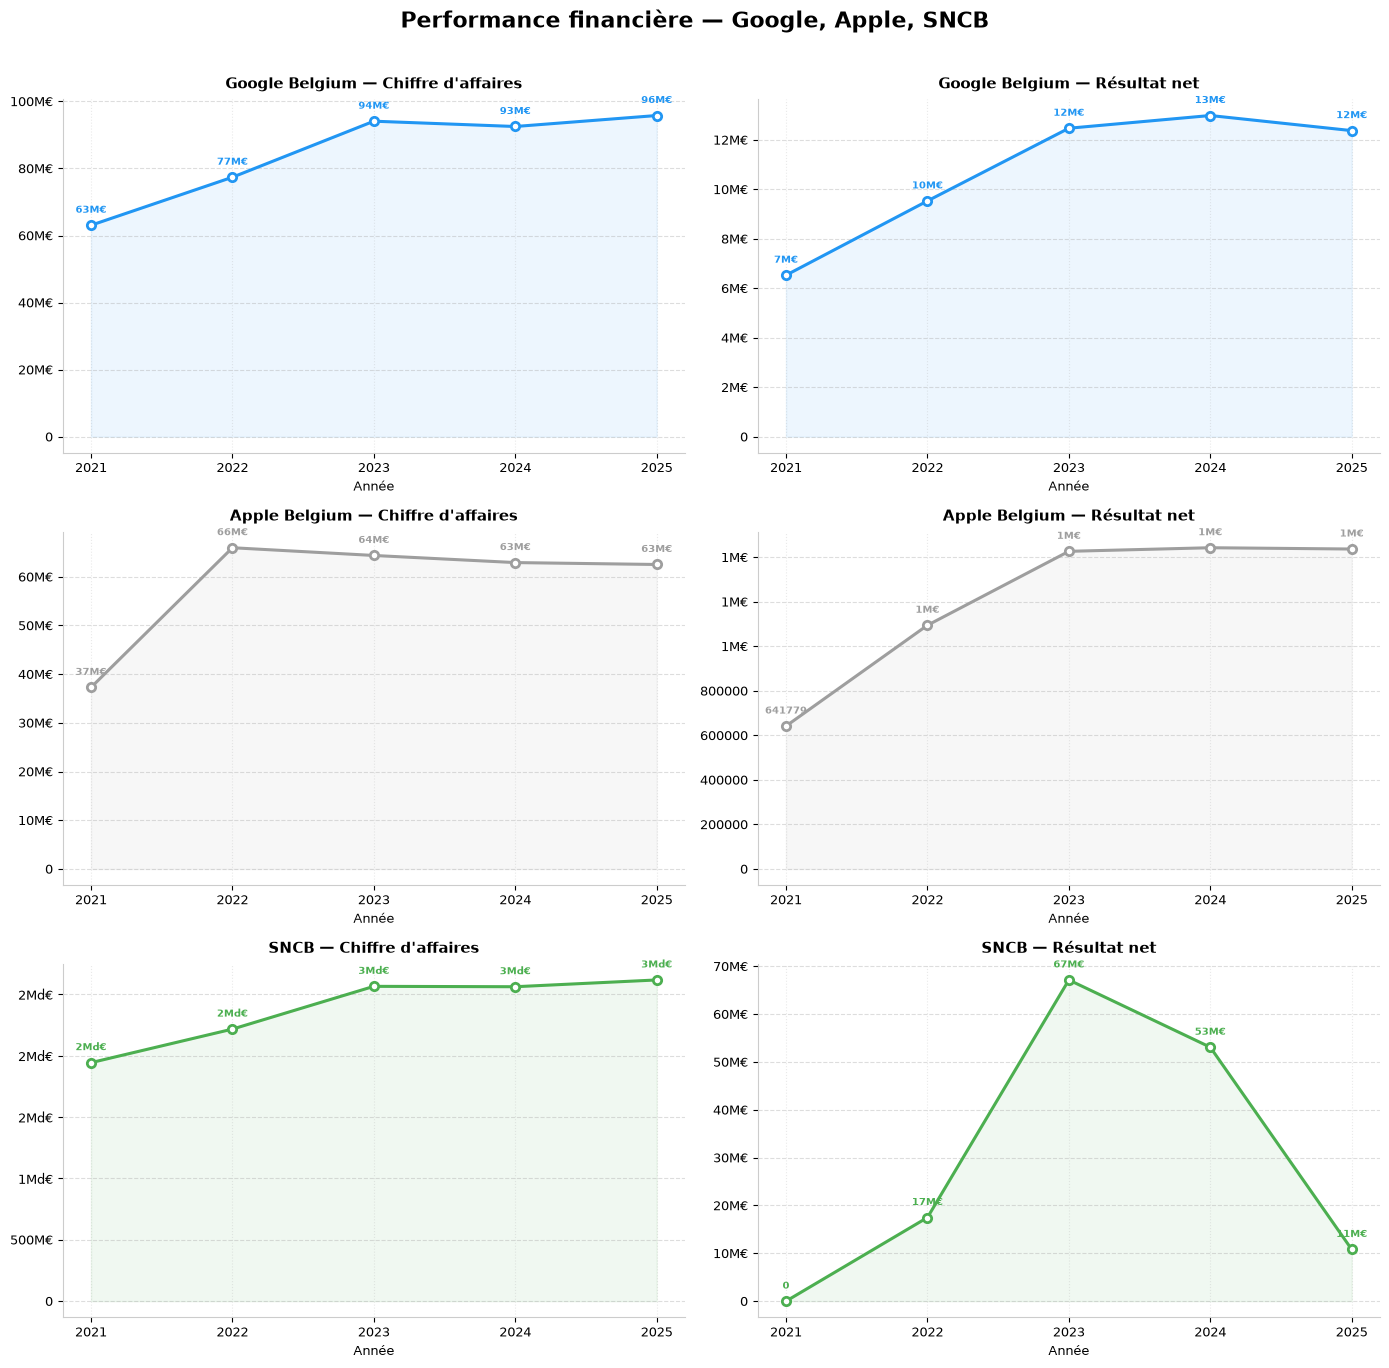

In [64]:
if not financiers:
    print("Aucune donnée financière — exécuter d'abord extraire_financiers_pdf.")
else:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import numpy as np

    # ── Palette par entreprise ────────────────────────────────────────────────────
    STYLES = {
        "Google Belgium":       {"color": "#2196F3", "marker": "o"},
        "Apple Belgium":        {"color": "#9E9E9E", "marker": "o"},
        "SNCB":                 {"color": "#4CAF50", "marker": "o"},
        "Apple Retail Belgium": {"color": "#9E9E9E", "marker": "o"},
    }

    def fmt_axe(v, _):
        if abs(v) >= 1e9:
            return f"{v/1e9:.0f}Md€"
        if abs(v) >= 1e6:
            return f"{v/1e6:.0f}M€"
        return f"{v:.0f}"

    entreprises = list(financiers.items())
    n = len(entreprises)

    fig, axes = plt.subplots(n, 2, figsize=(14, 4.5 * n))
    fig.suptitle("Performance financière — " + ", ".join(nom.split()[0] for nom, _ in entreprises),
                 fontsize=16, fontweight="bold", y=1.01)

    for row, (nom, df) in enumerate(entreprises):
        style = STYLES.get(nom, {"color": "#607D8B", "marker": "o"})
        c = style["color"]
        mk = style["marker"]

        ax_ca = axes[row, 0] if n > 1 else axes[0]
        ax_rn = axes[row, 1] if n > 1 else axes[1]

        df_ok = df[df["chiffre_affaires"] > 0].copy()
        df_ok = df_ok[df_ok.index >= 2021]

        for ax, col, label in [
            (ax_ca, "chiffre_affaires", "Chiffre d'affaires"),
            (ax_rn, "resultat_net",     "Résultat net"),
        ]:
            if df_ok.empty or col not in df_ok.columns:
                ax.set_visible(False)
                continue

            serie = df_ok[col].dropna()
            ax.plot(serie.index, serie.values,
                    color=c, marker=mk, linewidth=2.2, markersize=6,
                    markerfacecolor="white", markeredgewidth=2)

            ax.fill_between(serie.index, serie.values, alpha=0.08, color=c)

            ax.set_title(f"{nom} — {label}", fontsize=11, fontweight="bold", pad=8)
            ax.set_xlabel("Année", fontsize=9)
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_axe))
            ax.tick_params(axis="both", labelsize=9)
            ax.set_xticks(serie.index)
            ax.grid(axis="y", linestyle="--", alpha=0.4, color="#AAAAAA")
            ax.grid(axis="x", linestyle=":",  alpha=0.25, color="#AAAAAA")
            ax.spines[["top", "right"]].set_visible(False)
            ax.spines[["left", "bottom"]].set_color("#CCCCCC")

            for x, y in zip(serie.index, serie.values):
                ax.annotate(fmt_axe(y, None),
                            xy=(x, y), xytext=(0, 9), textcoords="offset points",
                            ha="center", fontsize=7.5, color=c, fontweight="bold")

    fig.tight_layout()
    plt.show()


---
## 📖 Glossaire des indicateurs financiers

Tous les indicateurs ci-dessous sont calculés à partir des **codes comptables NBB** (Plan Comptable Minimum Normalisé).
Les codes entre parenthèses correspondent aux lignes du CSV téléchargé depuis la NBB.

---

### Performance

| Indicateur | Définition | Formule | Code(s) |
|---|---|---|---|
| **Chiffre d'affaires (CA)** | Revenu total généré par la vente de biens et services sur l'exercice | — | `70` |
| **Marge brute** | Ce qu'il reste après déduction du coût direct des marchandises vendues | CA − Coût des marchandises | `70 − 60` |
| **EBIT** *(Résultat d'exploitation)* | Bénéfice avant intérêts et impôts — mesure la performance opérationnelle pure | — | `9901` |
| **EBITDA** | EBIT avant amortissements — proxy du cash généré par l'exploitation | EBIT + Amortissements | `9901 + 630` |
| **Résultat net** | Bénéfice final après toutes les charges, intérêts et impôts | — | `9904` |

---

### Croissance & Marges

| Indicateur | Définition | Formule |
|---|---|---|
| **Taux de croissance du CA (%)** | Variation du chiffre d'affaires d'une année sur l'autre | `(CA_n − CA_{n-1}) / CA_{n-1} × 100` |
| **Taux de marge brute (%)** | Part de la marge brute dans le CA — reflète la rentabilité commerciale | `Marge brute / CA × 100` |
| **Marge nette (%)** | Part du résultat net dans le CA — résume la rentabilité globale | `Résultat net / CA × 100` |
| **Marge EBITDA (%)** | Capacité à générer du cash avant investissements et fiscalité | `EBITDA / CA × 100` |

---

### Autonomie Financière

| Indicateur | Définition | Formule | Code(s) |
|---|---|---|---|
| **Trésorerie** | Liquidités disponibles immédiatement (banque + caisse) | — | `54/58` |
| **Dettes financières** | Total des emprunts bancaires (long terme + court terme) | Dettes LT + Dettes CT | `17 + 43` |
| **Dette financière nette** | Endettement réel après déduction de la trésorerie disponible. Négatif = position de trésorerie nette (bonne santé) | Dettes financières − Trésorerie | `(17 + 43) − 54/58` |

---

### Solvabilité

| Indicateur | Définition | Formule | Code(s) |
|---|---|---|---|
| **Fonds propres** | Capital apporté par les actionnaires + bénéfices accumulés non distribués | — | `10/15` |
| **Total actif** | Ensemble des ressources économiques contrôlées par l'entreprise | — | `20/58` |
| **Autonomie financière (%)** | Part des actifs financée par les fonds propres (sans recours à la dette). Plus c'est élevé, plus l'entreprise est indépendante | `Fonds propres / Total actif × 100` |

---

### Ressources Humaines

| Indicateur | Définition | Formule | Code(s) |
|---|---|---|---|
| **Effectif FTE moyen** | Nombre moyen d'équivalents temps plein sur l'exercice | — | `9087` |
| **Coûts salariaux** | Rémunérations brutes + cotisations patronales + avantages extra-légaux | — | `62` |
| **Revenu par ETP** | CA généré en moyenne par chaque employé — mesure la productivité | `CA / Effectif FTE` |
| **Coût moyen par ETP** | Coût salarial total rapporté à un équivalent temps plein | `Coûts salariaux / Effectif FTE` |
| **Part salariale dans le CA (%)** | Poids des charges de personnel dans le chiffre d'affaires | `Coûts salariaux / CA × 100` |
| **Taxes payées** | Impôt des sociétés (ISOC) effectivement payé sur l'exercice | — | `670/3` |

## 3) Jour 2 — Silver Layer + Hôtellerie

**Objectifs :**
- Créer `enterprise_silver` depuis `enterprise_finale` (Bronze intacte)
- Filtrer le secteur hôtelier et charger la StateDB
- Scraper les dépôts CBSO/NBB 2021–2025

In [ ]:
import sys
sys.path.insert(0, "dags")

from db.mongo_client import get_db

db = get_db()
for name in ("enterprise_finale", "enterprise_silver", "enterprises", "download_state"):
    try:
        print(f"{name:20} : {db[name].count_documents({}):,}")
    except Exception as e:
        print(f"{name:20} : erreur — {e}")

In [ ]:
# Étape 1 — Bronze nested (une seule fois si enterprise_finale vide)
BUILD_FINALE = False  # True pour reconstruire

if BUILD_FINALE:
    from build_enterprise_finale import run as build_finale
    build_finale()
else:
    print("build_enterprise_finale ignoré (BUILD_FINALE=False)")

In [ ]:
# Étape 2 — Silver
from build_silver import run as build_silver

build_silver(source="auto")

sample = db.enterprise_silver.find_one({"EnterpriseNumber": GOOGLE_NUM})
if sample:
    print("StartDate:", sample.get("StartDate"))
    print("StatusLabel:", sample.get("StatusLabel"))
    print("JuridicalFormLabel:", sample.get("JuridicalFormLabel"))
    print("Activités:", len(sample.get("activities", [])))

In [ ]:
# Étape 3 — Filtre hôtellerie + seed StateDB
from filters.hotel import get_hotel_enterprises, HOTEL_NACE_CODES
from seed_hotel_state import seed

hotel_nums = get_hotel_enterprises(db)
print(f"Entreprises hôtellerie : {len(hotel_nums):,}")
print(f"Codes NACE : {sorted(HOTEL_NACE_CODES)}")
print(f"Exemples : {hotel_nums[:5]}")

# seed(limit=10)  # décommenter pour test
seed()

In [ ]:
# Étape 4 — Scraping CBSO hôtellerie (CSV 2021+)
import os
os.environ.setdefault("HDFS_URL", "http://localhost:9870")
os.environ.setdefault("HDFS_USER", "root")

from scrape_hotel_cbso import run_scrape

RUN_HOTEL_SCRAPE = False  # True pour lancer (limit recommandé au début)
if RUN_HOTEL_SCRAPE:
    run_scrape(limit=5)       # test
    # run_scrape()            # run complet
    # run_scrape(resume=True) # reprise après 429
else:
    print("Scraping ignoré (RUN_HOTEL_SCRAPE=False)")